<div style="font-size:30px; text-align:center; font-weight:bold;">
    Project 1 - Opossum
</div>

Student: Vedran Mitić 2123


---------------------------

# Table of contents
1. [DATASET IMPORT AND DESCRIPTIVE ANALYSIS](#1.-DATASET-IMPORT-AND-DESCRIPTIVE-ANALYSIS)
2. [MISSING DATA IMPUTATION](#2.-MISSING-DATA-IMPUTATION)
3. [GENDER CLASSIFICATION](#3.-GENDER-CLASSIFICATION)
4. [GEOGRAPHICAL REGION CLASSIFICATION](#4.-GEOGRAPHICAL-REGION-CLASSIFICATION)
5. [AGE PREDICTION](#5.-AGE-PREDICTION)
6. [CONCLUSION](#6.-CONCLUSION)


-------------------------

# 1. DATASET IMPORT AND DESCRIPTIVE ANALYSIS


In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import shap


In [2]:
file = 'possum.csv'

complete_set = pd.read_csv(file)

complete_set


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


--------------------

The dataset consists of **104** samples and **14** features.<br>
The features are:<br>
**case** – sample index (can be removed)<br>
**site** – location where the opossum was captured<br>
**Pop** – population to which the opossum belongs<br>
**sex** – sex<br>
**age** – age<br>
**hdlngth** – head length in mm<br>
**skullw** – skull width in mm<br>
**totlngth** – total length (body length) in cm<br>
**taill** – tail length in cm<br>
**footlgth** – foot length in mm<br>
**earconch** – ear conch length in mm<br>
**eye** – distance from the medial canthus to the lateral canthus of the right eye in mm<br>
**chest** – chest circumference in cm<br>
**belly** – belly circumference in cm<br>

In [3]:
complete_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


---------

It can be seen that only two columns have the *object* data type — **Pop** and **sex**, which is beneficial for further work when these values need to be encoded.

In [4]:
print(complete_set["Pop"].unique())
print(complete_set["sex"].unique())


['Vic' 'other']
['m' 'f']


Both columns have only two possible values, which is convenient because they can be represented with values **0** and **1**, i.e., encoded using One-Hot Encoding.<br>
The value **Vic** means that the location is Victoria, while **other** indicates *South Wales* or *Queensland*.

---------------------------------------------------------------------------------------------------------------------
Since the *case* column represents simple sample indexing and pandas already provides this functionality, this column can be removed from the table.

In [5]:
complete_set = complete_set.drop(["case"],axis=1)

In [6]:
complete_set.head()

,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


The *case* column has been removed, and the number of columns has been reduced to **13**.

In [7]:
complete_set.describe()


,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


From the first row showing the number of values for each feature, it can be seen that the **age** and **footlgth** columns contain **two** and **one** NaN values, respectively.<br>
Here is the distribution of some columns, such as **site**, **age**, **Pop**, and **sex**:<br>

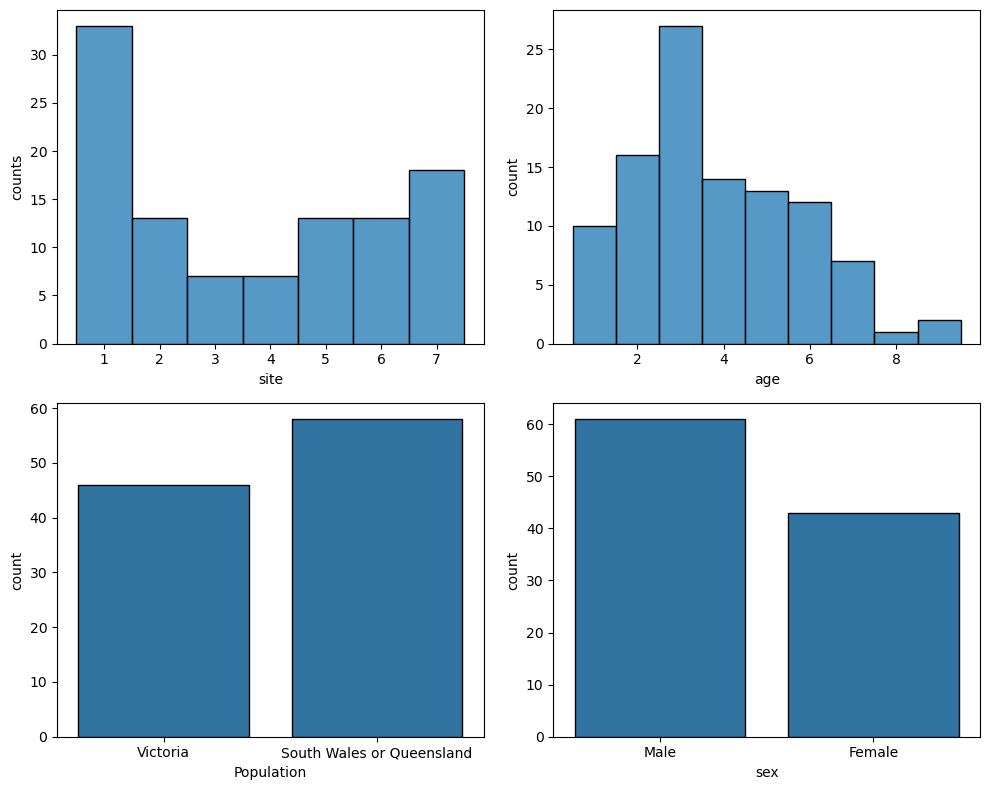

site
1    33
7    18
2    13
5    13
6    13
3     7
4     7
Name: count, dtype: int64


age
3.0    27
2.0    16
4.0    14
5.0    13
6.0    12
1.0    10
7.0     7
9.0     2
8.0     1
Name: count, dtype: int64


Pop
other    58
Vic      46
Name: count, dtype: int64


sex
m    61
f    43
Name: count, dtype: int64


In [8]:
plt.figure(figsize = (10,8))

plt.subplot(2,2,1)
sns.histplot(x='site', data = complete_set, discrete = True)
plt.xlabel("site")
plt.ylabel("counts")

plt.subplot(2,2,2)
sns.histplot(x = 'age', data = complete_set, discrete = True)
plt.xlabel('age')
plt.ylabel('count')

plt.subplot(2,2,3)
sns.countplot(x = complete_set["Pop"].map({"Vic":"Victoria","other":"South Wales or Queensland"}),data = complete_set, edgecolor = 'black')
plt.xlabel('Population')
plt.ylabel('count')

plt.subplot(2,2,4)
sns.countplot(x=complete_set["sex"].map({"m":"Male","f":"Female"}), data = complete_set, edgecolor = 'black')
plt.xlabel('sex')
plt.ylabel('count')

plt.tight_layout()
plt.show()


print(complete_set['site'].value_counts())
print('\n')
print(complete_set['age'].value_counts())
print('\n')
print(complete_set['Pop'].value_counts())
print('\n')
print(complete_set['sex'].value_counts())



From the provided plots, the following can be observed:<br>

1. Site plot
 - By far the largest number of opossums were captured at location 1.

 - The remaining opossums were captured in approximately equal numbers at the other locations, meaning that locations 3 and 4, as well as 2, 5, and 6, have a similar number of captures.

 - By comparing this with the .describe() table, we can see that the large number of ones is the reason why the min and 25th percentile values are equal.

2. Age plot

 - The largest number of opossums are 3 years old and are fairly evenly distributed across the other age groups, with only three samples aged 8 and 9. It should also be taken into account that this feature is missing two samples.

3. Population plot

 - Opossums are almost evenly distributed between the two classes. The Victoria class contains fewer opossums, likely because the other class represents a combination of two geographical regions.

4. Sex plot

 - Opossums are almost evenly distributed between the two classes.

Since *age* and *footlgth* contain missing values, it is necessary to identify which samples they correspond to:

In [9]:
x = complete_set[complete_set['age'].isnull()]
x


,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
43,2,Vic,m,NaN,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0
45,2,Vic,m,NaN,91.4,54.4,84.0,35.0,72.8,51.2,14.4,24.5,35.0


In [10]:
y = complete_set[complete_set['footlgth'].isnull()]
y

,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
40,2,Vic,f,5.0,88.4,57.0,83.0,36.5,NaN,40.3,15.9,27.0,30.5


It can be seen that the common characteristics of these samples are **site = 2** and **Pop = Vic**.<br>

--------------------------------------------------------------------------------------------------------------------

In [11]:
complete_set.groupby(['sex'])[['age']].mean()


,age
sex,
f,3.976744
m,3.728814


In [12]:
complete_set.groupby('sex')[['age']].median()

,age
sex,
f,4.0
m,3.0


The average age of male and female opossums is almost identical. The slightly higher average for females is likely caused by the outlier ***9***. For females, half of the samples are younger than 4 years, while for males, half are younger than 3.

In [13]:
complete_set.groupby(['sex'])['site'].apply(lambda x: x.mode()[0]).reset_index(name='most_common_site')

,sex,most_common_site
0,f,1
1,m,1


Both female and male opossums were most frequently captured at location 1.

In [14]:
complete_set.groupby('sex')['site'].apply(lambda x:x.value_counts().iloc[0:3]).reset_index(name='most_common_site_counts').rename(columns = {'level_1':'site_number'})

,sex,site_number,most_common_site_counts
0,f,1,19
1,f,5,6
2,f,2,5
3,m,1,14
4,m,7,14
5,m,6,9


However, we can see that male opossums were actually captured just as often at location 7.

Graphical representations:

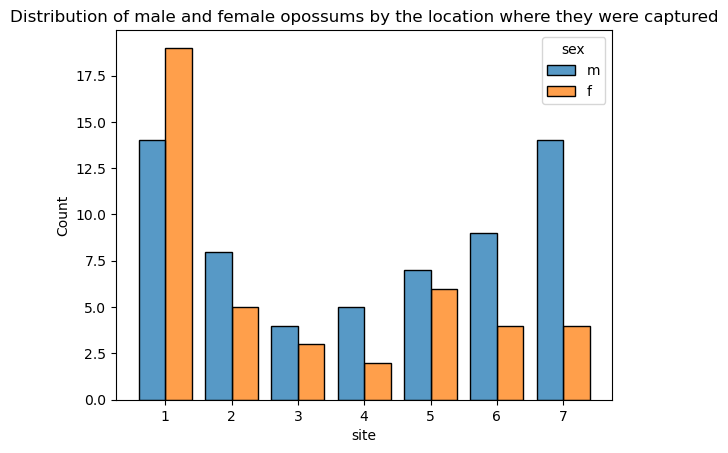

In [15]:
sns.histplot(data = complete_set, x = 'site', hue = 'sex', discrete = True, multiple = 'dodge', shrink = 0.8)
plt.title('Distribution of male and female opossums by the location where they were captured')
plt.show()

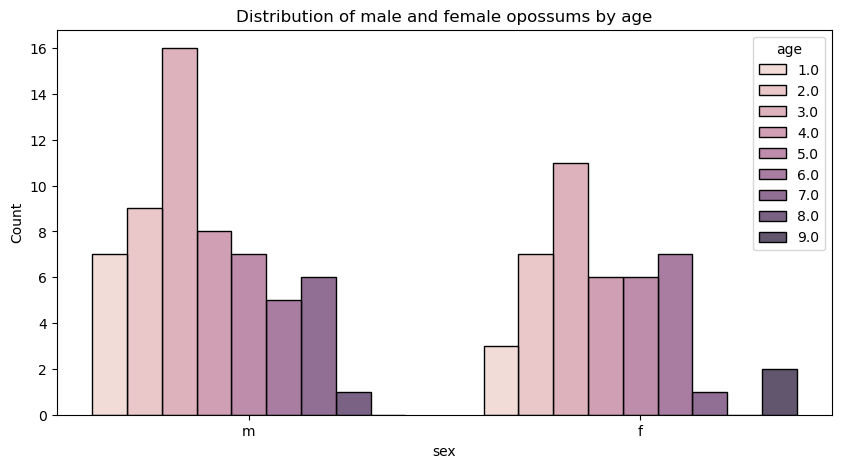

In [16]:
plt.figure(figsize = (10,5))
sns.histplot(data = complete_set, x = 'sex', hue = 'age', shrink = 0.8, discrete = True, multiple = 'dodge')
plt.title('Distribution of male and female opossums by age')
plt.show()



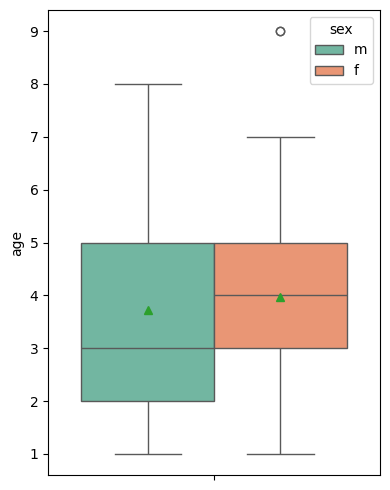

In [17]:
plt.figure(figsize = (4,5))
sns.boxplot(data = complete_set, hue = 'sex', y = 'age', palette = 'Set2', showmeans = True)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------

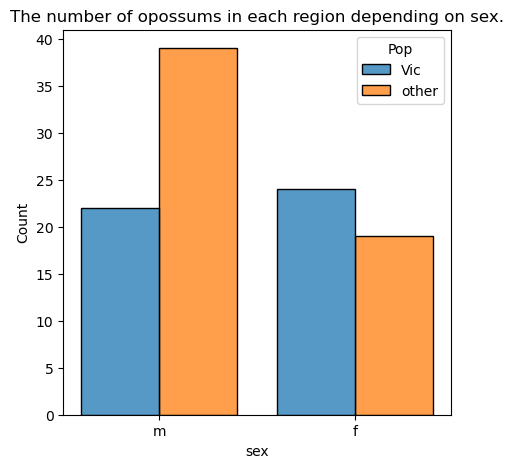

sex       
f    Vic      24
     other    19
m    other    39
     Vic      22
Name: Pop, dtype: int64

In [18]:
plt.figure(figsize = (5,5))
sns.histplot(data = complete_set, x = 'sex', hue = 'Pop', multiple = 'dodge', shrink = 0.8)
plt.title('The number of opossums in each region depending on sex.')
plt.show()
complete_set.groupby('sex')['Pop'].apply(lambda x: x.value_counts())

In [19]:
complete_set.groupby('Pop')['site'].apply(lambda x: x.value_counts())

Pop     
Vic    1    33
       2    13
other  7    18
       5    13
       6    13
       3     7
       4     7
Name: site, dtype: int64

From the output of the cell above, I obtained exactly what I wanted, which is to see which locations (sites) belong to which regions (Population). It can be seen that the region ***Victoria*** has only two locations, which is expected since ***other*** represents a combination of two regions.

------------------------------------------------------------------------------------------------------------------

In [20]:

modified_set = complete_set.drop(['age','Pop','site'], axis=1)
modified_set = modified_set.rename(columns={'hdlngth':'hdlngth[mm]' ,'skullw':'skullw[mm]','totlngth':'totlngth[cm]','taill':'taill[cm]','footlgth':'footlgth[mm]','earconch':'earconch[mm]','eye':'eye[mm]','chest':'chest[cm]','belly':'belly[cm]'})
modified_set_data = modified_set.groupby('sex').describe()
modified_set_data = modified_set_data.drop(['count','std','50%','25%','75%'], axis = 1, level = 1)

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)  
pd.set_option('display.expand_frame_repr', False) 
modified_set_data

hdlngth[mm]              skullw[mm]             totlngth[cm]              taill[cm]             footlgth[mm]             earconch[mm]                eye[mm]              chest[cm]              belly[cm]            
           mean   min    max       mean   min   max         mean   min   max       mean   min   max         mean   min   max         mean   min   max       mean   min   max       mean   min   max       mean   min   max
sex                                                                                                                                                                                                                       
f     92.148837  84.7   96.9  56.588372  51.5  67.7    87.906977  75.0  96.5  37.104651  32.0  41.0    69.111905  60.3  77.9    48.576744  40.3  53.9  14.811628  13.0  17.4  27.337209  23.0  31.0  32.883721  25.0  40.0
m     92.922951  82.5  103.1  57.091803  50.0  68.6    86.511475  76.0  96.0  36.942623  32.0  43.0    68.009836  62.0  75.0    47.816393  41.7  56.2  15.211475  12.8  17.8  26.762295  22.0  32.0  32.377049  27.0  38.0

In [21]:
modified_set.groupby('sex').median()

,hdlngth[mm],skullw[mm],totlngth[cm],taill[cm],footlgth[mm],earconch[mm],eye[mm],chest[cm],belly[cm]
sex,,,,,,,,,
f,92.5,56.4,88.5,37.5,70.45,50.8,14.8,28.0,33.0
m,93.2,56.3,86.0,36.5,66.90,46.4,15.0,27.0,32.0


Initially, I thought I would try to find whether there is any physical difference between male and female opossums, but all available data show that there are no significant differences in dimensions.<br>

Is there a difference in the type of opossum, i.e., which region it comes from?

In [22]:

modified_set = complete_set.drop(['age','sex','site'], axis=1)
modified_set = modified_set.rename(columns={'hdlngth':'hdlngth[mm]' ,'skullw':'skullw[mm]','totlngth':'totlngth[cm]','taill':'taill[cm]','footlgth':'footlgth[mm]','earconch':'earconch[mm]','eye':'eye[mm]','chest':'chest[cm]','belly':'belly[cm]'})
modified_set_data = modified_set.groupby('Pop').describe()
modified_set_data = modified_set_data.drop(['count','std','50%','25%','75%'], axis = 1, level = 1) 

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
modified_set_data

hdlngth[mm]              skullw[mm]             totlngth[cm]              taill[cm]             footlgth[mm]             earconch[mm]                eye[mm]              chest[cm]              belly[cm]            
             mean   min    max       mean   min   max         mean   min   max       mean   min   max         mean   min   max         mean   min   max       mean   min   max       mean   min   max       mean   min   max
Pop                                                                                                                                                                                                                         
Vic     92.597826  84.7   96.3  56.654348  51.5  67.7    87.467391  75.0  96.5  35.934783  32.0  39.5    72.397778  62.7  77.9    52.186957  40.3  56.2  14.871739  13.0  16.4  27.445652  23.0  31.0  32.663043  25.0  40.0
other   92.606897  82.5  103.1  57.065517  50.0  68.6    86.787931  80.5  96.0  37.862069  34.0  43.0    65.403448  60.3  73.2    44.913793  41.3  48.0  15.184483  12.8  17.8  26.646552  22.0  32.0  32.525862  27.0  39.0

In [23]:
modified_set.groupby('Pop').median()

,hdlngth[mm],skullw[mm],totlngth[cm],taill[cm],footlgth[mm],earconch[mm],eye[mm],chest[cm],belly[cm]
Pop,,,,,,,,,
Vic,93.15,56.3,89.0,36.0,72.8,52.15,14.9,28.0,32.5
other,92.40,56.4,86.5,38.0,65.2,44.90,15.0,26.0,32.5


The data are balanced here as well. I will try to split them into even smaller parts.

In [24]:

modified_set = complete_set.drop(['age','site'], axis=1)
modified_set = modified_set.rename(columns={'hdlngth':'hdlngth[mm]' ,'skullw':'skullw[mm]','totlngth':'totlngth[cm]','taill':'taill[cm]','footlgth':'footlgth[mm]','earconch':'earconch[mm]','eye':'eye[mm]','chest':'chest[cm]','belly':'belly[cm]'})
modified_set_data = modified_set.groupby(['sex','Pop']).describe()
modified_set_data = modified_set_data.drop(['count','std','50%','25%','75%'], axis = 1, level = 1)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
modified_set_data

hdlngth[mm]              skullw[mm]             totlngth[cm]              taill[cm]             footlgth[mm]             earconch[mm]                eye[mm]              chest[cm]              belly[cm]            
                 mean   min    max       mean   min   max         mean   min   max       mean   min   max         mean   min   max         mean   min   max       mean   min   max       mean   min   max       mean   min   max
sex Pop                                                                                                                                                                                                                         
f   Vic     92.412500  84.7   95.9  56.645833  51.5  67.7    88.333333  75.0  96.5  36.333333  32.0  39.5    73.021739  68.7  77.9    51.758333  40.3  53.9  14.695833  13.0  16.0  27.750000  23.0  31.0  32.541667  25.0  40.0
    other   91.815789  86.0   96.9  56.515789  52.0  59.9    87.368421  81.5  93.0  38.078947  36.0  41.0    64.378947  60.3  68.2    44.557895  41.3  47.2  14.957895  13.0  17.4  26.815789  25.0  31.0  33.315789  28.5  39.0
m   Vic     92.800000  85.1   96.3  56.663636  51.5  60.4    86.522727  76.0  93.0  35.500000  32.0  39.5    71.745455  62.7  75.0    52.654545  49.5  56.2  15.063636  13.8  16.4  27.113636  23.0  31.0  32.795455  27.0  38.0
    other   92.992308  82.5  103.1  57.333333  50.0  68.6    86.505128  80.5  96.0  37.756410  34.0  43.0    65.902564  62.0  73.2    45.087179  41.7  48.0  15.294872  12.8  17.8  26.564103  22.0  32.0  32.141026  27.0  36.5

In [25]:
modified_set.groupby(['sex','Pop']).median()

hdlngth[mm]  skullw[mm]  totlngth[cm]  taill[cm]  footlgth[mm]  earconch[mm]  eye[mm]  chest[cm]  belly[cm]
sex Pop                                                                                                               
f   Vic          92.95        56.3          89.5      36.25         72.80          52.1    14.80       28.0       33.0
    other        91.90        56.4          88.0      38.00         64.10          44.2    14.80       26.0       33.5
m   Vic          93.40        56.4          87.5      35.50         72.55          52.3    14.95       27.0       32.0
    other        92.80        56.3          85.0      38.00         65.60          44.9    15.00       26.0       32.0

I will combine all the data together:

In [26]:
median_data = modified_set.groupby(['sex','Pop']).median()
median_data.columns = pd.MultiIndex.from_product([median_data.columns,['median']])

#modified_set_merged = pd.concat([modified_set_data, median_data], axis=1) 
modified_set_merged = pd.merge(modified_set_data, median_data, left_index = True, right_index=True)
modified_set_merged = modified_set_merged.sort_index(axis=1)
modified_set_merged

belly[cm]                         chest[cm]                         earconch[mm]                         eye[mm]                         footlgth[mm]                         hdlngth[mm]                         skullw[mm]                         taill[cm]                         totlngth[cm]                        
                max       mean median   min       max       mean median   min          max       mean median   min     max       mean median   min          max       mean median   min         max       mean median   min        max       mean median   min       max       mean median   min          max       mean median   min
sex Pop                                                                                                                                                                                                                                                                                                                              
f   Vic        40.0  32.541667   33.0  25.0      31.0  27.750000   28.0  23.0         53.9  51.758333   52.1  40.3    16.0  14.695833  14.80  13.0         77.9  73.021739  72.80  68.7        95.9  92.412500  92.95  84.7       67.7  56.645833   56.3  51.5      39.5  36.333333  36.25  32.0         96.5  88.333333   89.5  75.0
    other      39.0  33.315789   33.5  28.5      31.0  26.815789   26.0  25.0         47.2  44.557895   44.2  41.3    17.4  14.957895  14.80  13.0         68.2  64.378947  64.10  60.3        96.9  91.815789  91.90  86.0       59.9  56.515789   56.4  52.0      41.0  38.078947  38.00  36.0         93.0  87.368421   88.0  81.5
m   Vic        38.0  32.795455   32.0  27.0      31.0  27.113636   27.0  23.0         56.2  52.654545   52.3  49.5    16.4  15.063636  14.95  13.8         75.0  71.745455  72.55  62.7        96.3  92.800000  93.40  85.1       60.4  56.663636   56.4  51.5      39.5  35.500000  35.50  32.0         93.0  86.522727   87.5  76.0
    other      36.5  32.141026   32.0  27.0      32.0  26.564103   26.0  22.0         48.0  45.087179   44.9  41.7    17.8  15.294872  15.00  12.8         73.2  65.902564  65.60  62.0       103.1  92.992308  92.80  82.5       68.6  57.333333   56.3  50.0      43.0  37.756410  38.00  34.0         96.0  86.505128   85.0  80.5

*Note: Obviously, at the beginning of this work I did not pay enough attention and did not notice the differences that exist depending on the geographical location. It can be seen, as will also be shown during algorithm testing, that there are differences in the characteristics earconch, footlgth, and taill.*

---------------------------

# 2. MISSING DATA IMPUTATION


Encoding the columns that contain nominal values is done simply using OHE (One-Hot Encoding).

In [27]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_set = ohe.fit_transform(complete_set[['sex','Pop']])
feature_names = ohe.get_feature_names_out(['sex','Pop'])

ohe_Dataframe = pd.DataFrame(ohe_set, columns = feature_names, index = complete_set.index)

complete_set_numeric = complete_set.drop(['sex','Pop'], axis = 1)
complete_set2 = pd.concat([complete_set_numeric,ohe_Dataframe], axis = 1)
complete_set2.head() 


,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,sex_f,sex_m,Pop_Vic,Pop_other
0,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0,0.0,1.0,1.0,0.0
1,1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0,1.0,0.0,1.0,0.0
2,1,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0,1.0,0.0,1.0,0.0
3,1,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0,1.0,0.0,1.0,0.0
4,1,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0,1.0,0.0,1.0,0.0


Handling the ***NaN*** values in the table.

In [28]:
print(complete_set.groupby(['sex','Pop'])['age'].mean())
print(complete_set.groupby(['sex','Pop'])['age'].median())

sex  Pop  
f    Vic      4.041667
     other    3.894737
m    Vic      4.000000
     other    3.589744
Name: age, dtype: float64
sex  Pop  
f    Vic      4.0
     other    3.0
m    Vic      3.0
     other    3.0
Name: age, dtype: float64


## 2.1. KNN version:


In [29]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaled_set = scaler.fit_transform(complete_set2)

imputer = KNNImputer(n_neighbors=10)

scaled_set_imputed = imputer.fit_transform(scaled_set)
scaled_set_imputed = scaler.inverse_transform(scaled_set_imputed)
scaled_set_imputed = pd.DataFrame(scaled_set_imputed)

imputed_set = imputer.fit_transform(complete_set2)
imputed_set = pd.DataFrame(imputed_set)


print(scaled_set_imputed.iloc[[40,43,45]])
print(imputed_set.iloc[[40,43,45]])

broj = scaled_set_imputed.iloc[43][1]
broj

     0    1     2     3     4     5      6     7     8     9     10   11   12   13   14
40  2.0  5.0  88.4  57.0  83.0  36.5  68.08  40.3  15.9  27.0  30.5  1.0  0.0  1.0  0.0
43  2.0  2.7  85.1  51.5  76.0  35.5  70.30  52.6  14.4  23.0  27.0  0.0  1.0  1.0  0.0
45  2.0  3.9  91.4  54.4  84.0  35.0  72.80  51.2  14.4  24.5  35.0  0.0  1.0  1.0  0.0
     0    1     2     3     4     5      6     7     8     9     10   11   12   13   14
40  2.0  5.0  88.4  57.0  83.0  36.5  63.07  40.3  15.9  27.0  30.5  1.0  0.0  1.0  0.0
43  2.0  2.5  85.1  51.5  76.0  35.5  70.30  52.6  14.4  23.0  27.0  0.0  1.0  1.0  0.0
45  2.0  3.3  91.4  54.4  84.0  35.0  72.80  51.2  14.4  24.5  35.0  0.0  1.0  1.0  0.0


np.float64(2.6999999999999997)

<div style="font-size:18px;"> I compared the results obtained with and without prior scaling:<br> - Row <b>40</b> contained a NaN value for the **footlgth** column, which is at index <b>6</b>: with scaling (first table), the value is <b>68.08</b>, which is about <b>5 mm</b> higher and also closer to the average value.<br> - Rows <b>43</b> and <b>45</b> contained NaN values for the **age** column, which is at index <b>1</b>: if standard mathematical rounding is used (where sample <b>43</b> with <b>2.5</b> years would get the value <b>3</b>), a difference can be seen in the results where sample <b>45</b> would get <b>4</b> (3.9) with scaling, while without scaling it would get <b>3</b> (3.3).<br> Since scaling gives equal importance to all features in KNN, I will consider the scaled values. </div>

In [30]:
indexs_age = complete_set2[complete_set2['age'].isnull()].index.tolist() 
index_Age = complete_set2.columns.get_loc('age') 

indexs_lng = complete_set2[complete_set2['footlgth'].isnull()].index.tolist() 
index_Lng = complete_set2.columns.get_loc('footlgth') 


age_Values = scaled_set_imputed.iloc[indexs_age][index_Age].round().tolist()
lng_Values = scaled_set_imputed.iloc[indexs_lng][index_Lng].tolist()
print(age_Values)
print(lng_Values)

complete_set2.loc[indexs_age,'age'] = age_Values
complete_set2.loc[indexs_lng,'footlgth'] = lng_Values

complete_set2.iloc[[40,43,45]]

[3.0, 4.0]
[68.08]


,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,sex_f,sex_m,Pop_Vic,Pop_other
40,2,5.0,88.4,57.0,83.0,36.5,68.08,40.3,15.9,27.0,30.5,1.0,0.0,1.0,0.0
43,2,3.0,85.1,51.5,76.0,35.5,70.30,52.6,14.4,23.0,27.0,0.0,1.0,1.0,0.0
45,2,4.0,91.4,54.4,84.0,35.0,72.80,51.2,14.4,24.5,35.0,0.0,1.0,1.0,0.0


<div style="font-size:20px;"> IMPORTANT! </div>

The previous code cell will work, but if we try to run it again, it will no longer do anything except the line <b>complete_set2.iloc[[40,43,45]]</b>. This is because the table has already been updated and the variables used above will be empty. That is why I locate the rows using manually entered indices at the end, rather than using the variables. Therefore, the variables for the indices need to be preserved.

------------------------------------------

The dataset is now complete. Updated graphical representation of the age distribution:

age
3.0    27
2.0    16
4.0    14
5.0    13
6.0    12
1.0    10
7.0     7
9.0     2
8.0     1
Name: count, dtype: int64
age
3.0    28
2.0    16
4.0    15
5.0    13
6.0    12
1.0    10
7.0     7
9.0     2
8.0     1
Name: count, dtype: int64


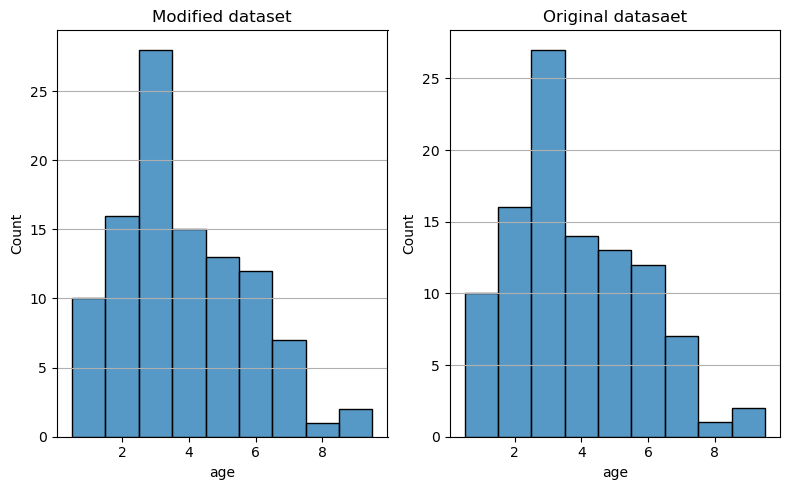

In [31]:

plt.figure(figsize = (8,5))
plt.subplot(1,2,1)
sns.histplot(data = complete_set2, x = 'age', discrete = True)
plt.title('Modified dataset')
plt.grid(axis = 'y')

plt.subplot(1,2,2)
sns.histplot(data = complete_set, x = 'age', discrete = True)
plt.title('Original datasaet')

plt.tight_layout()
plt.grid(axis = 'y')

print(complete_set['age'].value_counts())
print(complete_set2['age'].value_counts())


Graphically, it can be seen that the values on the y-axis are slightly narrower.

----------------------------------------

## 2.2. CORRELATION MATRIX

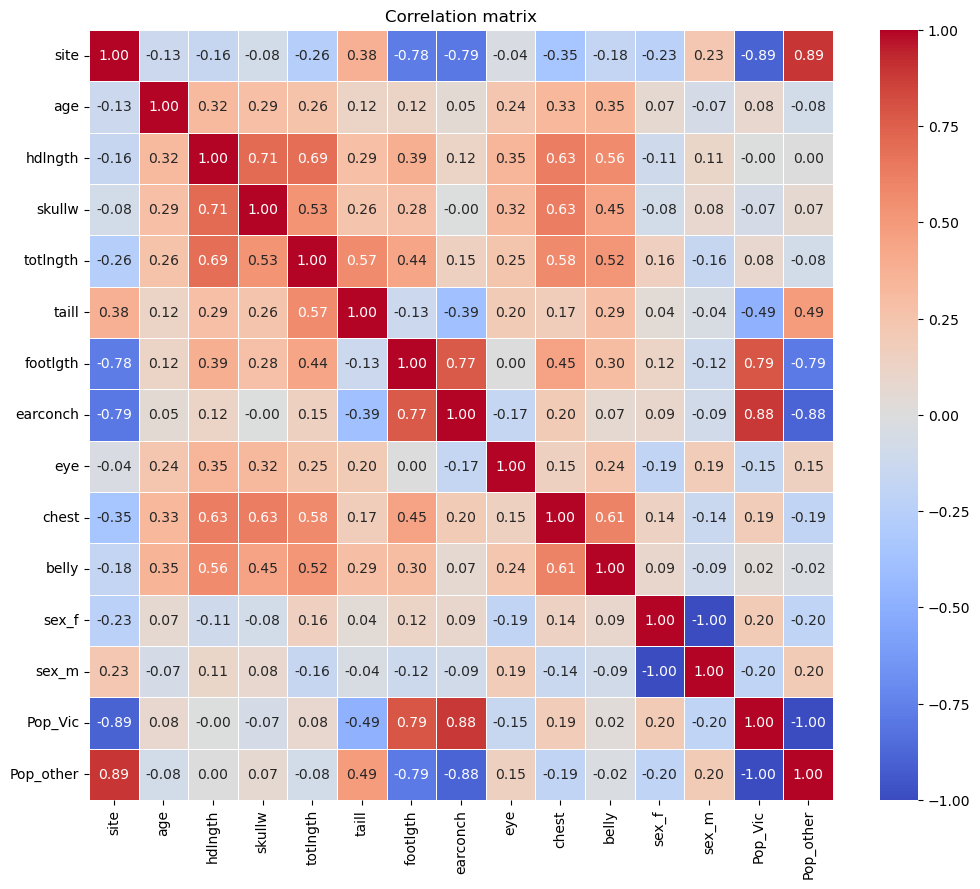

In [32]:
corr_matrix = complete_set2.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, center=0)            

plt.title('Correlation matrix')
plt.show()

The correlation coefficient between the attributes ***site*** and ***Pop*** is 0.89, which is extremely high. Generally, a correlation value greater than 0.9 can be considered redundant and could justify dropping one of the attributes. This is further evidence that the ***site*** column can be removed — which I previously concluded (as stated later in the work) based on feature importance. This reduces model complexity while retaining essential information.<br>

It can also be seen that the sex attributes are very weakly correlated with almost all other attributes, indicating a barely noticeable difference between sexes — practically all attributes are noise.<br>

The attributes ***footlgth*** and ***earconch*** are clearly highly correlated with the ***Pop*** columns, which aligns with the SHAP plot for region classification. Their mutual correlation is also high — 0.77. This made me think about the consequences of dropping one of these attributes. I arrived at the following conclusion: Taking, for example, the classification of opossums by region where the accuracy is 100%, and where dimensionality was reduced to these two attributes using Lasso, dropping one of them beforehand would make the classification rely either solely on the remaining attribute or on the remaining attribute and some other attribute(s) that Lasso would keep instead of the dropped one (I’m not sure? I will test this later). If it were the first case, it could happen that the model misclassifies an individual (e.g., an outlier) — in that case, having the previously dropped attribute would be useful, because the classification could be redirected to the correct result based on it, thereby increasing the model’s robustness.

#    3. GENDER CLASSIFICATION


## 3.1. Logistic regression


In [33]:
from sklearn.model_selection import train_test_split

X = complete_set2.drop(['sex_f','sex_m','site'], axis = 1)
y = complete_set2['sex_f']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 25)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#complete_set2_scaled = pd.DataFrame(scaler.fit_transform(complete_set2),columns = complete_set2.columns, index=complete_set2.index)

print(X_train_scaled.round().mean())
print(X_train_scaled.round().std())


0.017361111111111112
1.0244350200669177


It can be seen that the theory is confirmed: StandardScaler sets the mean to 0 and the standard deviation to 1.

Accuracy:0.65625


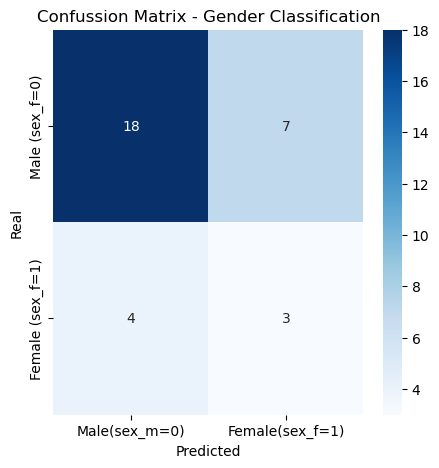

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
predicted = logreg.predict(X_test_scaled)

print(f"Accuracy:{accuracy_score(y_test, predicted)}")

cmatrix = confusion_matrix(y_test,predicted)

plt.figure(figsize = (5,5))

sns.heatmap(cmatrix, annot = True, fmt='d', cmap = 'Blues', xticklabels=['Male(sex_m=0)','Female(sex_f=1)'], yticklabels=['Male (sex_f=0)', 'Female (sex_f=1)'])

plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confussion Matrix - Gender Classification')

plt.show()


In [35]:
result = pd.DataFrame({"Real":y_test,"Predicted":predicted}, index=X_test.index)

indeksF = result[result['Real'] != result['Predicted']].index
indeksT = result[result['Real'] == result['Predicted']].index
idxF = indeksF[0]
idxT = indeksT[0]

In [36]:
from lime import lime_tabular
#from IPython.display import display, HTML


explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Male', 'Female'],
    mode='classification'
)

pos_u_testu = np.where(X_test.index == idxF)[0][0]

exp = explainer_lime.explain_instance(
    data_row=X_test_scaled[pos_u_testu],
    predict_fn=logreg.predict_proba
)

#html_data = exp.as_html(show_table=True)
#display(HTML(html_data))

exp.show_in_notebook(show_table=True)

In [37]:
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Male', 'Female'],
    mode='classification'
)

pos_u_testu = np.where(X_test.index == idxT)[0][0]

exp = explainer_lime.explain_instance(
    data_row=X_test_scaled[pos_u_testu],
    predict_fn=logreg.predict_proba
)


exp.show_in_notebook(show_table=True)

By comparing the two graphs above, the problem of poor classification and the model’s inability to handle the data can be fundamentally understood. The first graph represents a misclassified male, showing the scaled values of all features and the thresholds against which the model decided whether the sample was male or female based on the values it had. The second graph represents the same thing but for a correctly classified male. It can be observed that the male in both cases has completely different feature values, so it is even normal that the model saw them differently. For example, the model classifies a sample as female if it has a smaller head and larger chest and skull width; and as male if it has a larger head and smaller chest and skull width. If you also look at the age value for both samples on the LIME plots, you can see that it has the same value of -0.9, which would mean that in both cases, it is a young individual with the same number of years. This comparison of two randomly chosen results becomes significant also because the age factor can be removed from the classification.

-----------

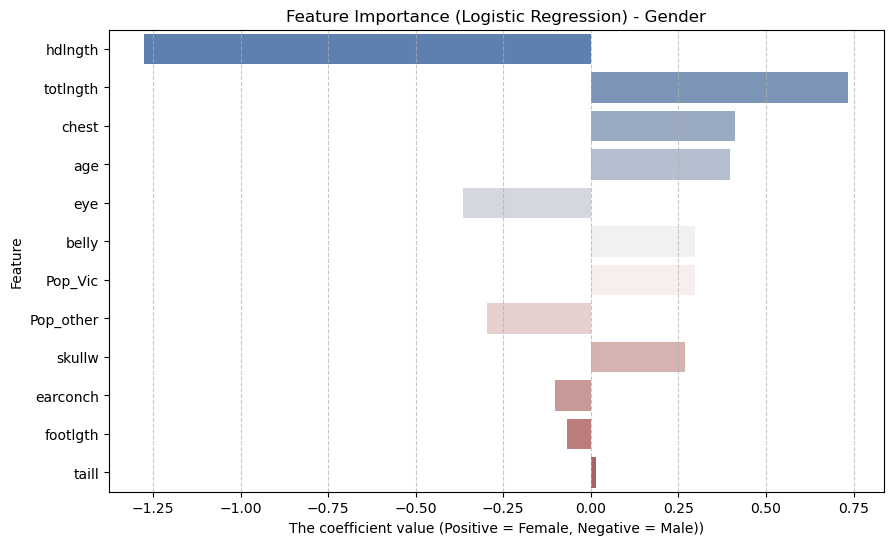

In [38]:
importance = logreg.coef_[0]
features = X.columns

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})

feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='vlag', hue = 'Feature', legend = False)
plt.title('Feature Importance (Logistic Regression) - Gender')
plt.xlabel('The coefficient value (Positive = Female, Negative = Male))')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


It can be seen that the idea of dropping the ***site*** column increased the accuracy by 15%.

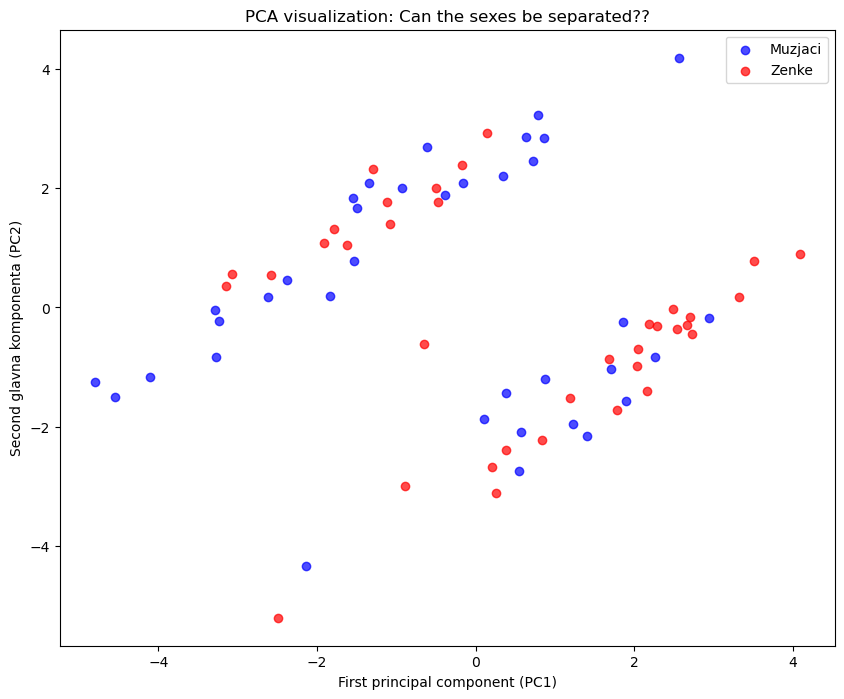

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[y_train==0, 0], X_pca[y_train==0, 1], color='blue', label='Muzjaci', alpha=0.7)
plt.scatter(X_pca[y_train==1, 0], X_pca[y_train==1, 1], color='red', label='Zenke', alpha=0.7)
plt.xlabel('First principal component (PC1)')
plt.ylabel('Second glavna komponenta (PC2)')
plt.legend()
plt.title('PCA visualization: Can the sexes be separated??')
plt.show()

It is clear why logistic regression fails here: the data are not separable; in fact, they form two clusters that contain both males and females.

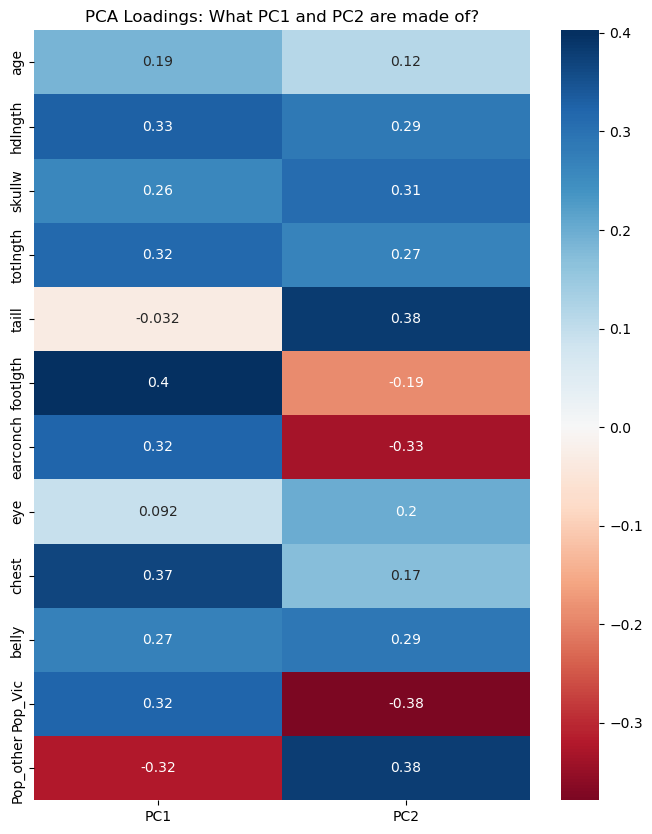

In [40]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

plt.figure(figsize=(8, 10))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('PCA Loadings: What PC1 and PC2 are made of?')
plt.show()

PC1 measures the size of the opossum: the larger it is, the higher the PC1 value, and it is placed on the right side of the plot.<br>
PC2 separates the populations based on whether they are from Victoria or others, and by the sizes of earconch, tail, and footlgth.

In [41]:
complete_set.groupby('Pop')[['earconch','taill','footlgth']].mean()

,earconch,taill,footlgth
Pop,,,
Vic,52.186957,35.934783,72.397778
other,44.913793,37.862069,65.403448


In [42]:
complete_set.groupby('sex')[['earconch','taill','footlgth']].mean()

,earconch,taill,footlgth
sex,,,
f,48.576744,37.104651,69.111905
m,47.816393,36.942623,68.009836


It is clear that, unlike sex, opossums can be separated based on geographical location.

-------------------------------

-------------------------------

*NOTE*: The results shown in the output cells are the results obtained after the site column was removed. The original results with the site column were as follows:<br><br>

*"Accuracy is: 0.5 <br>
It can be seen that the algorithm performed poorly, practically guessing 50%-50%. Although the test set contained a larger number of males, the algorithm did not learn to distinguish them from females during training. Out of 25 male samples, as many as 11 were classified as female, while out of 7 female samples, only 2 were correctly classified.<br>
<br>
This was somewhat expected because the data do not appear to be separable; males and females are physically quite similar to each other.<br>*

![Matrica konfuzije](https://raw.githubusercontent.com/vekiii/ai-and-machine-learning/44a70b300583594eda235c8aa4bd5a8f649e31fe/machine-learning-projects/project1/1.JPG)

![Feature_Importance](https://raw.githubusercontent.com/vekiii/ai-and-machine-learning/9205626678a42450004b65fd05d6d742ef9d40f1/machine-learning-projects/project1/2.JPG)

*From the Feature Importance plot, it can be seen that the site column significantly influenced the classification of males. Therefore, I will remove this column, and it also makes no sense to use it because it is a subgroup of the Pop column, to which certain sites clearly belong.*

-----------------------------------

-----------------------------------

## 3.2 Additional test – removing all less important attributes

Accuracy is:0.625


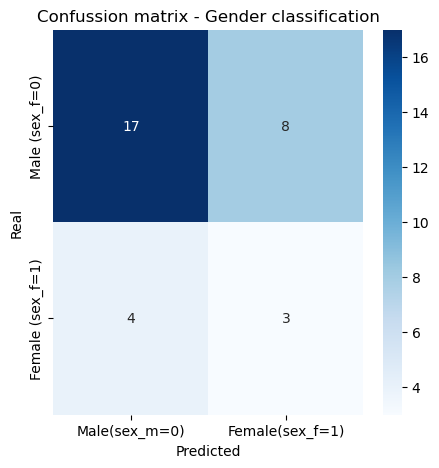

In [43]:
X = complete_set2[['hdlngth','totlngth','chest','eye','belly']]
y = complete_set2['sex_f']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 25, test_size = 0.3)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

predicted = logreg.predict(X_test_scaled)

print(f"Accuracy is:{accuracy_score(y_test,predicted)}")

cmatrix = confusion_matrix(y_test,predicted)

plt.figure(figsize = (5,5))

sns.heatmap(cmatrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Male(sex_m=0)','Female(sex_f=1)'], yticklabels=['Male (sex_f=0)', 'Female (sex_f=1)'])

plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confussion matrix - Gender classification')

plt.show()

The results show that the “reduced” model maintains practically the same performance (a drop from 0.65 to 0.625), which confirms the hypothesis that the remaining features do not carry predictive value for sex classification. This achieves a significantly simpler and more interpretable model with minimal loss of accuracy, indicating that the low accuracy is due to biological overlap between sexes rather than poor feature selection.

In [44]:
result = pd.DataFrame({"Real":y_test,"Predicted":predicted}, index=X_test.index)

indeksF = result[result['Real'] != result['Predicted']].index
indeksT = result[result['Real'] == result['Predicted']].index
idxF = indeksF[0]
idxT = indeksT[0]

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Male', 'Female'],

    mode='classification'
)

pos_u_testu = np.where(X_test.index == idxF)[0][0]

exp = explainer_lime.explain_instance(
    data_row=X_test_scaled[pos_u_testu],
    predict_fn=logreg.predict_proba
)

exp.show_in_notebook(show_table=True)

In [45]:
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Male', 'Female'],
    mode='classification'
)

pos_u_testu = np.where(X_test.index == idxT)[0][0]

exp = explainer_lime.explain_instance(
    data_row=X_test_scaled[pos_u_testu],
    predict_fn=logreg.predict_proba
)

exp.show_in_notebook(show_table=True)

In the first result for the misclassified male, it can be seen that the model was even more confident in choosing female, based on the same values as in the first experiment, because it is most likely the same sample. This indicates that the removed attributes acted as stabilizers.<br>

For the correctly classified male, this time the most influential decision factor was totlngth (previously it was hdlngth). It can also be noted that all five reduced features have completely opposite values compared to the previous example; every feature that pushed the prediction toward female in the first example now pushes toward male, and vice versa. This means that the model was able to correctly identify males in two cases for two different opossums (although the probability of 0.56 does not indicate a very confident decision).

## 3.3. Support Vector Machines


In [46]:
from sklearn.svm import SVC

svm = SVC(kernel = "rbf", random_state = 25, gamma = 'scale', C=1, class_weight = 'balanced')
svm.fit(X_train_scaled,y_train)

svm_predicted = svm.predict(X_test_scaled)
print(f"Accuracy:{accuracy_score(y_test,svm_predicted)}")
#print(f1_score(y_test,svm_predicted))

Accuracy:0.625


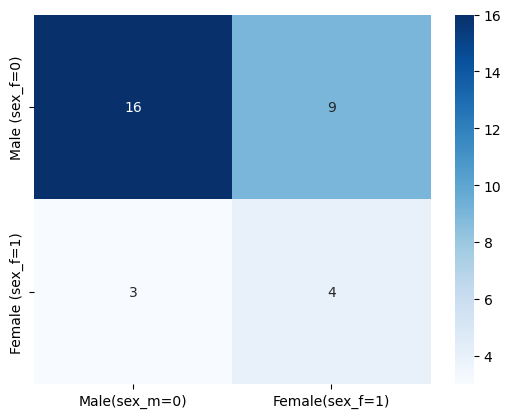

In [47]:
cmatrix = confusion_matrix(y_test,svm_predicted)

sns.heatmap(cmatrix, annot = True, fmt='d', cmap = 'Blues', xticklabels =['Male(sex_m=0)','Female(sex_f=1)'], yticklabels=['Male (sex_f=0)', 'Female (sex_f=1)'])
plt.show()

The grouped values above are associated with males, while the grouped values below are associated with females.

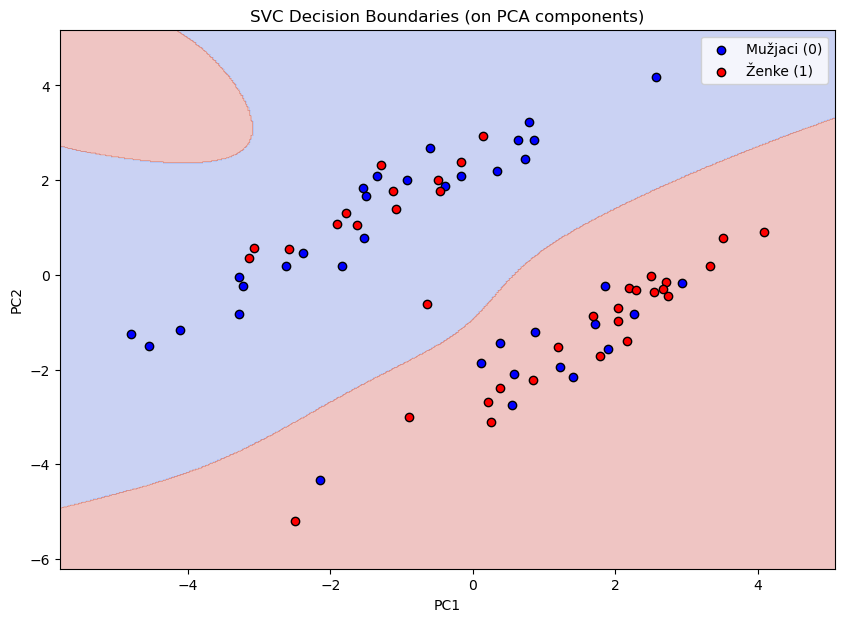

In [48]:
svm_viz = SVC(kernel="rbf", gamma='scale', C=1, class_weight='balanced')
svm_viz.fit(X_pca, y_train)

h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3) # Boja pozadine (granica)

plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1], c='blue', edgecolors='k', label='Mužjaci (0)')
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], c='red', edgecolors='k', label='Ženke (1)')

plt.title('SVC Decision Boundaries (on PCA components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 3.4. Conclusion


It is very difficult, almost impossible, to determine the sex of an opossum based on its physical characteristics! The accuracy might improve by choosing a different random_state.

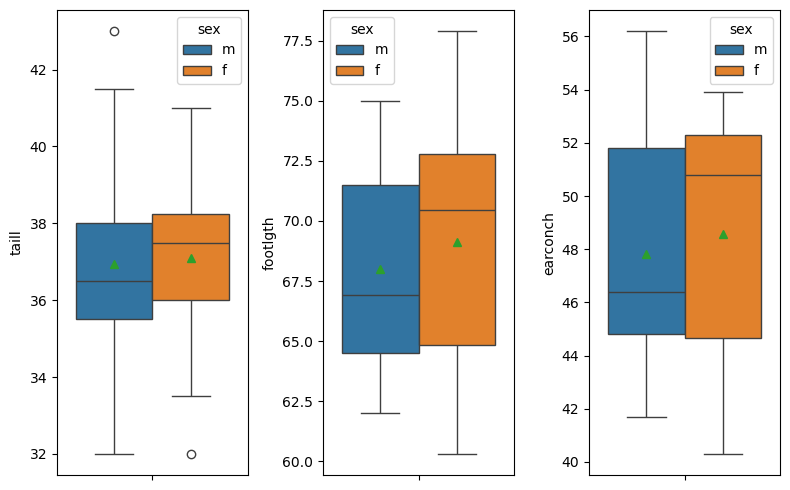

In [49]:
plt.figure(figsize = (8,5))

plt.subplot(1,3,1)
sns.boxplot(data = complete_set, y = 'taill', hue = 'sex', showmeans = True)

plt.subplot(1,3,2)
sns.boxplot(data = complete_set, y = 'footlgth', hue = 'sex', showmeans = True)

plt.subplot(1,3,3)
sns.boxplot(data = complete_set, y = 'earconch', hue = 'sex', showmeans = True)

plt.tight_layout()

----------------------------------------------------

# 4. GEOGRAPHICAL REGION CLASSIFICATION


## 4.1. Pipeline - Logistic regression and SVM

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X = complete_set2.drop(['site','Pop_Vic','Pop_other'], axis = 1)
y = complete_set2['Pop_Vic']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.4, random_state = 25) #povecao sam malo test skup

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pipe = Pipeline([('classifier',SVC())]) 

parameters = [{'classifier':[LogisticRegression(max_iter = 1000, solver = 'liblinear')],
              'classifier__C':[0.1, 1, 10, 50, 100],
              'classifier__penalty':['l1','l2'],
              'classifier__class_weight':[None,'balanced']},
              {'classifier':[SVC()],
              'classifier__C':[0.1, 1, 10, 50, 100],
              'classifier__gamma':['scale', 'auto'],
              'classifier__class_weight':[None,'balanced'],
              'classifier__kernel':['rbf','poly','linear','sigmoid']}
             ]

scores = {'Accuracy':'accuracy',
          'F1_score':'f1',
          'Recall':'recall'}

gscv = GridSearchCV(pipe, parameters,cv =5, scoring = scores, verbose = 2, refit = 'F1_score', n_jobs = -1)

gscv.fit(X_train_scaled,y_train)



Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,"Pipeline(step...ier', SVC())])"
,param_grid,"[{'classifier': [LogisticRegre...r='liblinear')], 'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1', 'l2']}, {'classifier': [SVC()], 'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 'auto'], ...}]"
,scoring,"{'Accuracy': 'accuracy', 'F1_score': 'f1', 'Recall': 'recall'}"
,n_jobs,-1
,refit,'F1_score'
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [51]:
print(f"Best parameters (based on F1): {gscv.best_params_}")
print(f"Best F1 score: {gscv.best_score_:.4f}")

results = pd.DataFrame(gscv.cv_results_).sort_values(by = ['rank_test_F1_score'])
#print(results_df[['params', 'mean_test_Accuracy', 'mean_test_F1_Score', 'mean_test_Recall']].sort_values(by='mean_test_F1_Score', ascending=False).head())
results[results['rank_test_F1_score'] == 1][['rank_test_F1_score','rank_test_Accuracy','rank_test_Recall','param_classifier','mean_test_Accuracy','mean_test_F1_score','mean_test_Recall','param_classifier__C','param_classifier__class_weight','param_classifier__penalty']]


Best parameters (based on F1): {'classifier': LogisticRegression(max_iter=1000, solver='liblinear'), 'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
Best F1 score: 0.9846


,rank_test_F1_score,rank_test_Accuracy,rank_test_Recall,param_classifier,mean_test_Accuracy,mean_test_F1_score,mean_test_Recall,param_classifier__C,param_classifier__class_weight,param_classifier__penalty
0,1,1,6,"LogisticRegression(max_iter=1000, solver='libl...",0.984615,0.984615,0.971429,0.1,None,l1
37,1,1,6,SVC(),0.984615,0.984615,0.971429,1.0,None,NaN
41,1,1,6,SVC(),0.984615,0.984615,0.971429,1.0,None,NaN
45,1,1,6,SVC(),0.984615,0.984615,0.971429,1.0,balanced,NaN
52,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,None,NaN
53,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,None,NaN
56,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,None,NaN
57,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,None,NaN
60,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,balanced,NaN
61,1,1,6,SVC(),0.984615,0.984615,0.971429,10.0,balanced,NaN


The best model turned out to be Logistic Regression with hyperparameters C=0.1 and l1, although the table shows that there are several other winning combinations. l1 (Lasso) set some irrelevant features to 0 on its own.

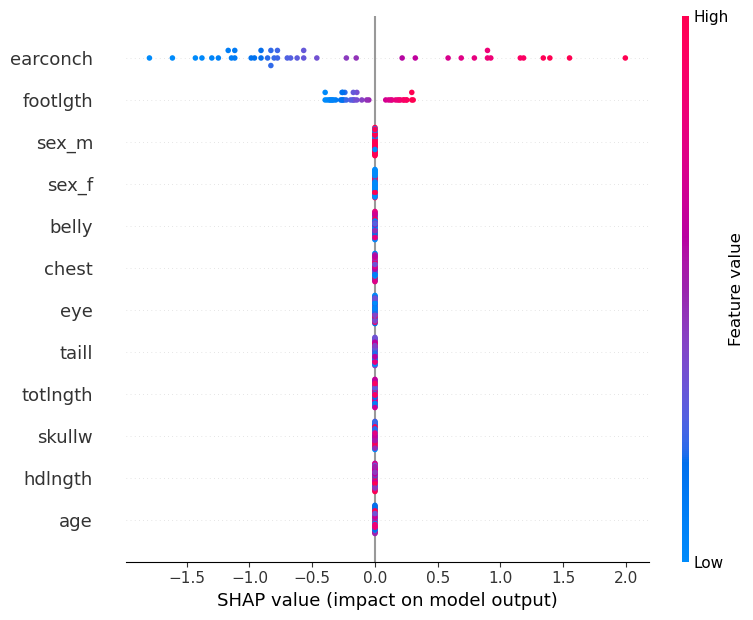

In [52]:

best_logic = gscv.best_estimator_.named_steps['classifier']

explainer = shap.LinearExplainer(best_logic, X_train_scaled, feature_names=X.columns.tolist())
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

This plot shows that the small difference that exists in the taill values was not taken into account at all; the focus was only on earconch and footlgth. The red dots, as shown in the legend, represent high values. Since they are on the right side of the plot, this means that the larger the opossum’s values for these features, the more characteristic it is of the Victoria class. On the other hand, the blue dots, which represent lower values, indicate that the smaller the opossum’s feature values, the less characteristic it is of the Victoria class, meaning it belongs to the others class.

Accuracy:1.0


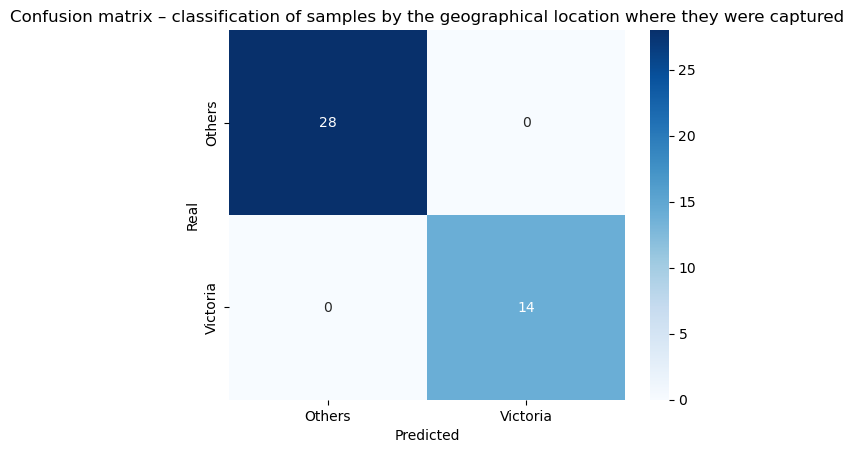

In [53]:
predicted = gscv.predict(X_test_scaled)

cmatrix = confusion_matrix(y_test, predicted)
sns.heatmap(cmatrix, annot=True,fmt='d',cmap='Blues',xticklabels =['Others','Victoria'], yticklabels=['Others', 'Victoria'])
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix – classification of samples by the geographical location where they were captured')
print(f'Accuracy:{accuracy_score(y_test,predicted)}')

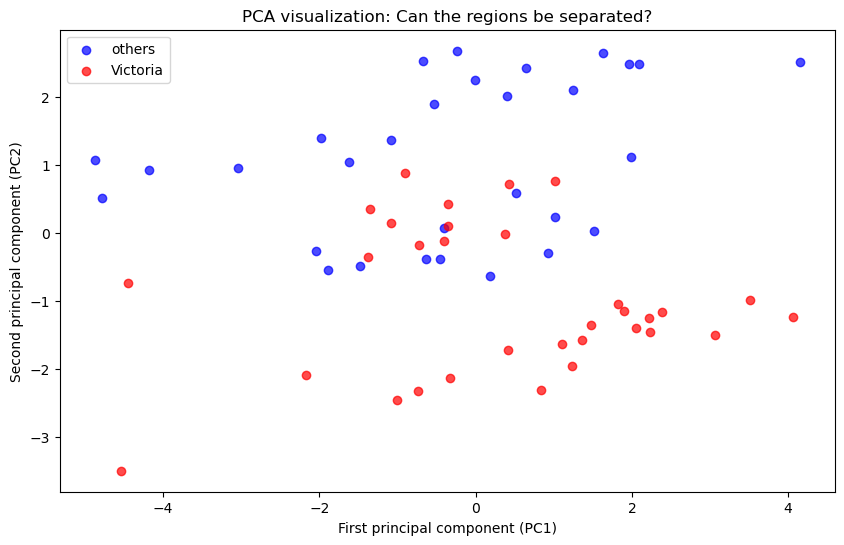

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y_train==0, 0], X_pca[y_train==0, 1], color='blue', label='others', alpha=0.7)
plt.scatter(X_pca[y_train==1, 0], X_pca[y_train==1, 1], color='red', label='Victoria', alpha=0.7)
plt.xlabel('First principal component (PC1)')
plt.ylabel('Second principal component (PC2)')
plt.legend()
plt.title('PCA visualization: Can the regions be separated?')
plt.show()

This plot looks much better because we have clearly distinct clusters in the lower and upper parts of the graph. Although PCA provides only a 2D projection of the data, the achieved classification accuracy of 100% indicates that the model is successfully finding a clear separating boundary between opossums from Victoria and those from others in the original high-dimensional space. Therefore, the PCA visualization is fully consistent with the model’s performance.

-----------------------------------------------------------

## 4.2.1. Additional example – robustness testing

As I previously planned, I will try removing either earconch or footlgth and observe the model’s behavior in that case.

Accuracy is: 0.9523809523809523


Text(0.5, 1.0, 'Confusion matrix 2 – classification of samples by the geographical location where they were captured')

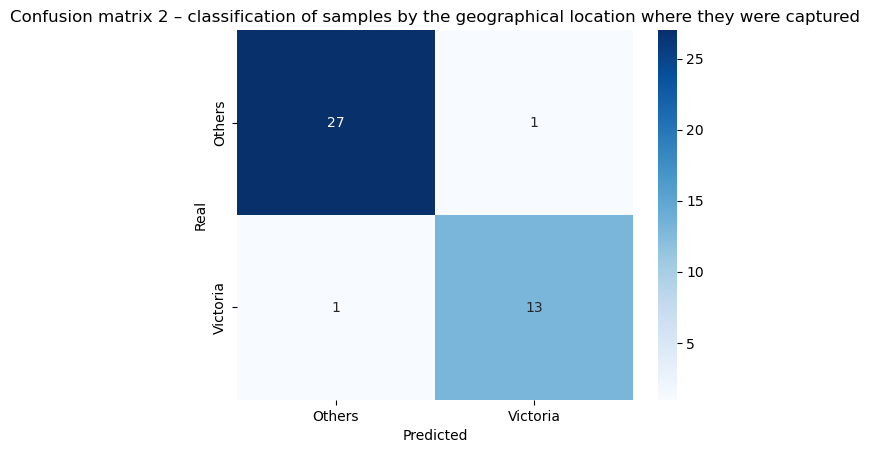

In [55]:
X = complete_set2.drop(['site','Pop_Vic','Pop_other','earconch'], axis = 1)
y = complete_set2['Pop_Vic']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.4, random_state = 25) 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter = 1000, solver = 'liblinear', C = 0.1, penalty = 'l1', class_weight = None)

logreg.fit(X_train_scaled, y_train)
predicted = logreg.predict(X_test_scaled)

print(f"Accuracy is: {accuracy_score(y_test, predicted)}")

cmatrix = confusion_matrix(y_test, predicted)

sns.heatmap(cmatrix, annot=True,fmt='d',cmap='Blues',xticklabels =['Others','Victoria'], yticklabels=['Others', 'Victoria'])
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix 2 – classification of samples by the geographical location where they were captured')





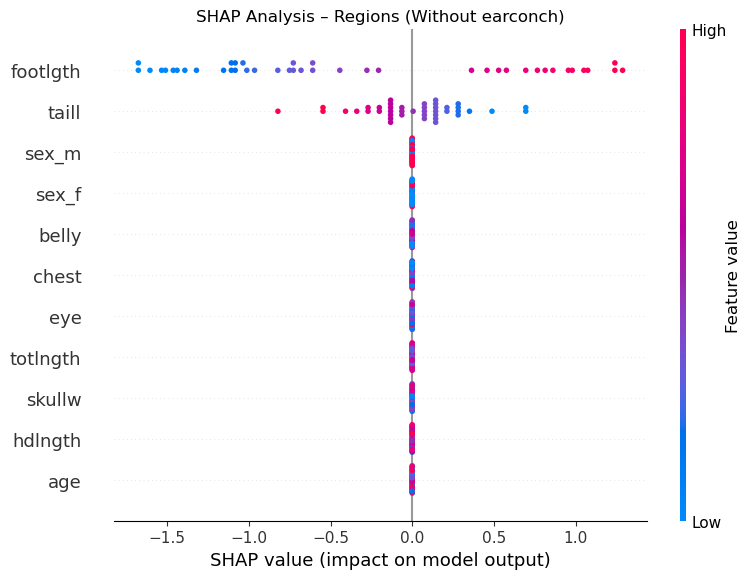

In [56]:
explainer = shap.LinearExplainer(logreg, X_train_scaled, feature_names=X.columns.tolist())
shap_values = explainer.shap_values(X_test_scaled)

plt.title('SHAP Analysis – Regions (Without earconch)')
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

Removing earconch reduced accuracy by about 5%, which is still a high result. This also proves that the other attributes are strong separators for opossums by region. The main difference in the SHAP plots is how the hierarchy of influential attributes changed. While earconch was present, footlgth played a secondary role. After removing earconch, the influence of footlgth on the plot increased threefold (range on the x-axis) — the model was forced to use it as the main factor. Also, as I noted in the first example when removing the taill attribute, it has now gained importance because Lasso recognized it as the next best source of information.

## 4.2.2. Additional example – final robustness testing

Accuracy is 0.7380952380952381


Text(0.5, 1.0, 'Confusion matrix 3 – classification of samples by the geographical location where they were captured')

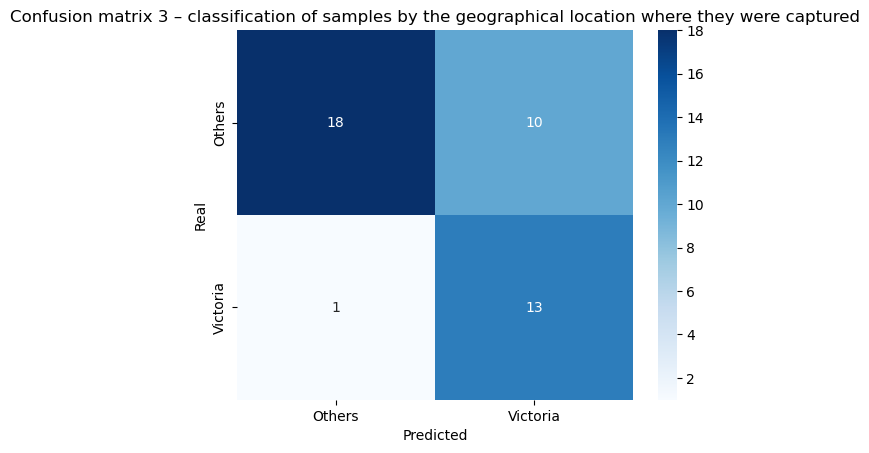

In [57]:
X = complete_set2.drop(['site','Pop_Vic','Pop_other','earconch','footlgth'], axis = 1)
y = complete_set2['Pop_Vic']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.4, random_state = 25) #povecao sam malo test skup

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter = 1000, solver = 'liblinear', C = 0.1, penalty = 'l1', class_weight = None)

logreg.fit(X_train_scaled, y_train)
predicted = logreg.predict(X_test_scaled)

print(f"Accuracy is {accuracy_score(y_test, predicted)}")

cmatrix = confusion_matrix(y_test, predicted)

sns.heatmap(cmatrix, annot=True,fmt='d',cmap='Blues',xticklabels =['Others','Victoria'], yticklabels=['Others', 'Victoria'])
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix 3 – classification of samples by the geographical location where they were captured')

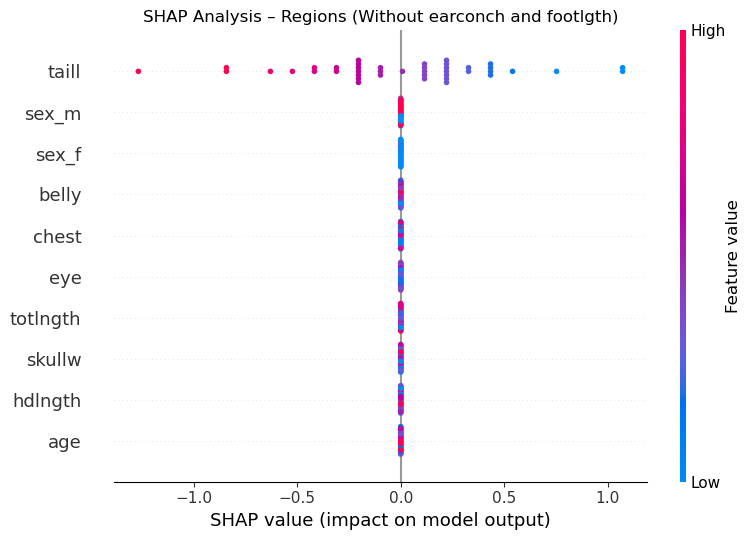

In [58]:
explainer = shap.LinearExplainer(logreg, X_train_scaled, feature_names=X.columns.tolist())
shap_values = explainer.shap_values(X_test_scaled)

plt.title('SHAP Analysis – Regions (Without earconch and footlgth)')
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

Accuracy is 0.6666666666666666


Text(0.5, 1.0, 'Confusion matrix 4 – classification of samples by the geographical location where they were captured')

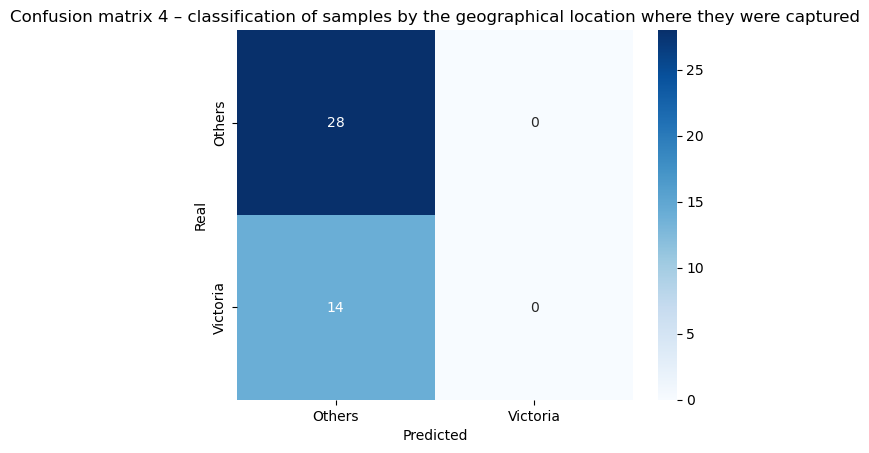

In [59]:
X = complete_set2.drop(['site','Pop_Vic','Pop_other','earconch','footlgth','taill'], axis = 1)
y = complete_set2['Pop_Vic']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.4, random_state = 25) #povecao sam malo test skup

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter = 1000, solver = 'liblinear', C = 0.1, penalty = 'l1', class_weight = None)

logreg.fit(X_train_scaled, y_train)
predicted = logreg.predict(X_test_scaled)

print(f"Accuracy is {accuracy_score(y_test, predicted)}")

cmatrix = confusion_matrix(y_test, predicted)

sns.heatmap(cmatrix, annot=True,fmt='d',cmap='Blues',xticklabels =['Others','Victoria'], yticklabels=['Others', 'Victoria'])
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix 4 – classification of samples by the geographical location where they were captured')

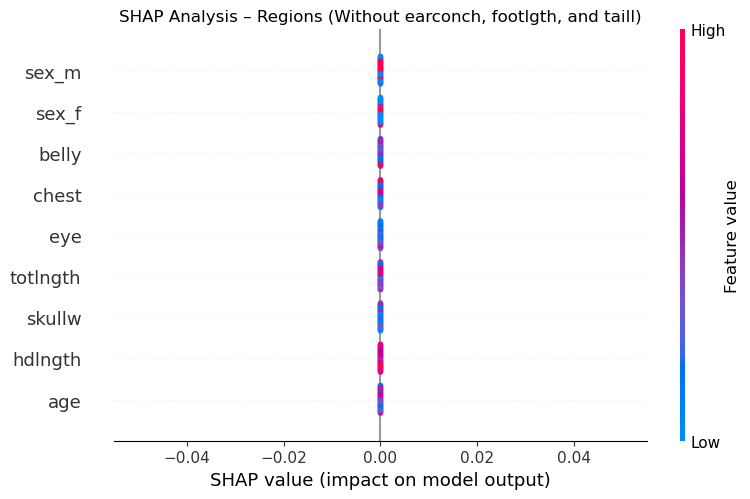

In [60]:
explainer = shap.LinearExplainer(logreg, X_train_scaled, feature_names=X.columns.tolist())
shap_values = explainer.shap_values(X_test_scaled)

plt.title('SHAP Analysis – Regions (Without earconch, footlgth, and taill)')
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

With the further removal of the most significant attributes, the accuracy value decreases:<br>

1. Removing footlgth – 73.80%; Lasso now relies on the model using only the taill feature, so the achieved accuracy can be described as classification based directly on tail length. 10 opossums from the other group were misclassified. This means that tails overlap much more between these two regions than ears and feet do.

2. Removing taill – 66.66%; there is no longer any feature capable of separating opossums by region. The obtained accuracy is the result of the model playing it safe and classifying all samples into the numerically larger class.

## 4.3. Conclusion
Opossums can be distinguished by physical build based on the geographical location they come from. <br>
The final robustness test showed the limit of the model’s predictive power; by removing three key morphological markers (ears, feet, tail), Lasso regularization eliminated all remaining attributes as statistically insignificant. At that point, the model stopped performing real classification and switched to a majority-class prediction strategy, confirming that the remaining measures (body and head) are insufficient for geographical separation of these populations.

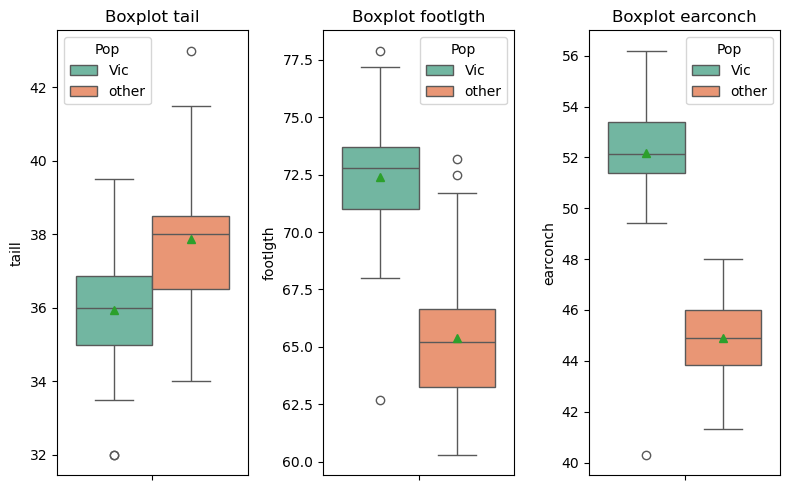

In [61]:
plt.figure(figsize = (8,5))
plt.subplot(1,3,1)
plt.title('Boxplot tail')
sns.boxplot(data = complete_set,y = 'taill', hue = 'Pop', palette = 'Set2', showmeans = True)

plt.subplot(1,3,2)
plt.title('Boxplot footlgth')
sns.boxplot(data = complete_set,y = 'footlgth', hue = 'Pop', palette = 'Set2', showmeans = True)

plt.subplot(1,3,3)
plt.title('Boxplot earconch')
sns.boxplot(data = complete_set,y = 'earconch', hue = 'Pop', palette = 'Set2', showmeans = True)

plt.tight_layout()


These three values are foot length, ear conch length, and tail length (to a lesser extent).<br>
And it has been confirmed graphically that the values of these three characteristics are distributed around different ranges depending on the geographical location (with some outliers).

---------------------------------------------------------------------------

# 5. AGE REGRESSION


## 5.1.1 Feature correlation

Text(0.5, 1.0, 'Correlation of features with age')

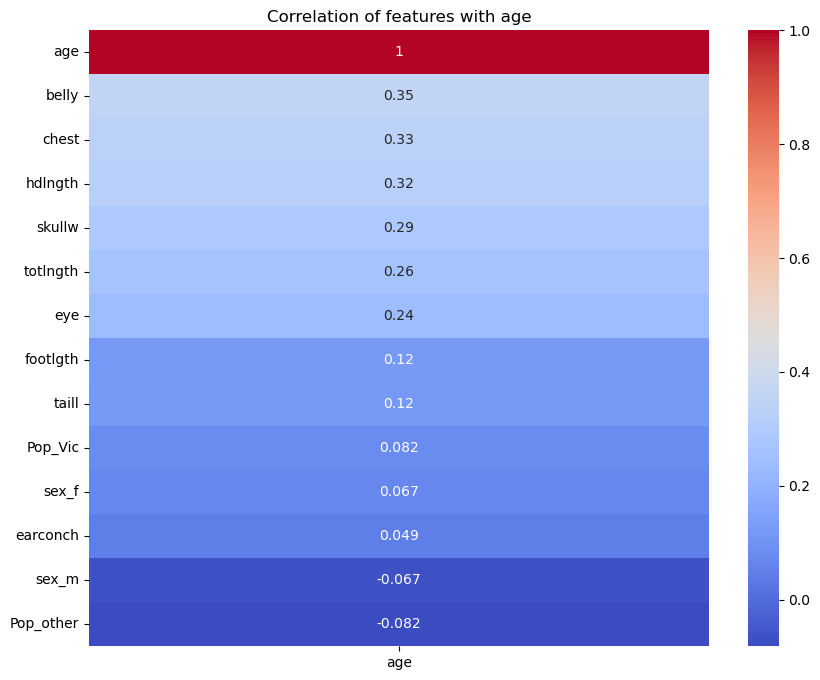

In [62]:

plt.figure(figsize=(10, 8))
sns.heatmap(complete_set2.drop(['site'],axis=1).corr()[['age']].sort_values(by='age', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Correlation of features with age")


It can be seen that there is no feature that indicates a high correlation with age.

## 5.1.2 Assessment of the age distribution quality

Skewness: 0.544
Kurtosis: -0.274
Mean: 3.83
Median: 3.00


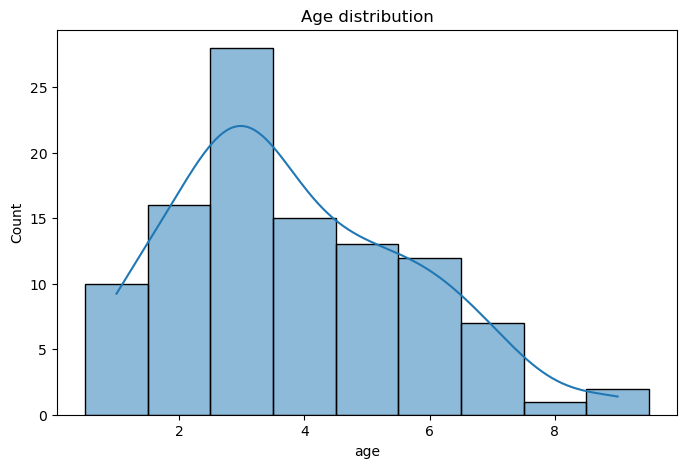

In [63]:
plt.figure(figsize = (8,5))
sns.histplot(data = complete_set2, x = 'age', discrete = True, kde = True)
plt.title('Age distribution')

from scipy.stats import skew, kurtosis

age_data = complete_set2['age']

s = skew(age_data)
k = kurtosis(age_data)

print(f"Skewness: {s:.3f}")
print(f"Kurtosis: {k:.3f}")

print(f"Mean: {age_data.mean():.2f}")
print(f"Median: {age_data.median():.2f}")

The age distribution analysis showed a moderate positive skewness (Skewness = 0.544), indicating that younger individuals dominate the sample (median age is 3 years). Since the kurtosis value (Kurtosis = -0.274) is close to zero, the distribution is sufficiently normal for regression to be performed on the original data without the need for a logarithmic transformation. However, the presence of a larger number of younger individuals explains why the sex classification model shows higher accuracy for individuals with smaller morphological measurements.

----------------------------------------------

Results obtained with Linear Regression:<br>
Mean Squared Error: 4.3862745528625<br>
R² Score: -0.2604554707952904<br>
Linear regression is completely unsuccessful with the given data. The RMSE is about 2.1 years, which is high for an age range of 1 to 9.

## 5.2. Pipeline – Polynomial Regression, Random Forest Regressor, and Support Vector Regressor

In [64]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression

X = complete_set2.drop(['site','age'], axis = 1)
y = complete_set2['age']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.35, random_state = 25)

pipe = Pipeline([('preprocessor',StandardScaler()),('poly',PolynomialFeatures(degree = 1)),('regressor',LinearRegression())])

algorithms = [{'poly':[None],'regressor':[RandomForestRegressor(random_state = 25)],
               'regressor__n_estimators':[10,100,500],
               'regressor__max_depth':[None, 5, 10]
              },
              {'poly':[PolynomialFeatures()],
               'regressor':[Ridge(max_iter=500)],
               'poly__degree': [1, 2],
               'regressor__alpha': [0.1, 1.0, 10.0]
              },
              {'poly':[None],
               'regressor':[SVR()],
               'regressor__kernel':['rbf','linear'],
               'regressor__C':[0.1, 1, 10, 50, 100],
               'regressor__gamma': ['scale', 'auto']}]

grids = GridSearchCV(pipe, algorithms, cv = 5, verbose = 1, scoring = 'r2', n_jobs = -1)

best_model = grids.fit(X_train,y_train)


Fitting 5 folds for each of 35 candidates, totalling 175 fits


In [65]:
print(best_model.best_estimator_)
print(best_model.best_params_)
print(best_model.best_score_)

Pipeline(steps=[('preprocessor', StandardScaler()), ('poly', None),
                ('regressor', SVR(C=1, gamma='auto'))])
{'poly': None, 'regressor': SVR(), 'regressor__C': 1, 'regressor__gamma': 'auto', 'regressor__kernel': 'rbf'}
0.15253626717869193


The R² result is no longer negative, but it is still very low, which means that even the best model produced a very poor result. In other words, age is difficult to predict based on the known characteristics.

## 5.4. Additional - SFS (Sequential Feature Selection)

Attribute: 1 | MSE: 3.1591 | R2: 0.0675
Attribute: 2 | MSE: 3.0858 | R2: 0.1149
Attribute: 3 | MSE: 2.9411 | R2: 0.1775
Attribute: 4 | MSE: 2.9209 | R2: 0.1838
Attribute: 5 | MSE: 2.9583 | R2: 0.1749
Attribute: 6 | MSE: 2.9753 | R2: 0.1484
Attribute: 7 | MSE: 2.9754 | R2: 0.1507
Attribute: 8 | MSE: 2.9859 | R2: 0.1464
Attribute: 9 | MSE: 2.9832 | R2: 0.1424
Attribute: 10 | MSE: 3.0038 | R2: 0.1370
Attribute: 11 | MSE: 3.0224 | R2: 0.1232
Attribute: 12 | MSE: 3.1021 | R2: 0.0983
Attribute: 13 | MSE: 3.1705 | R2: 0.0690


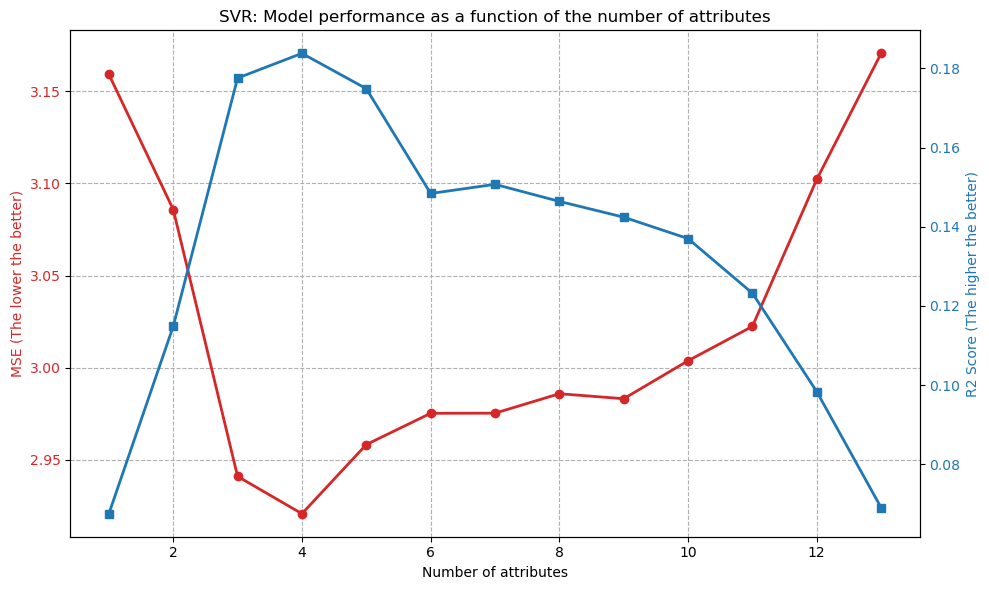


The best model is obtained with 4 attributes.
Best R2 score: 0.1838


In [66]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svr = SVR(kernel='rbf', C=1, gamma = 'auto') 

mse_list = []
r2_list = []
n_features = X.shape[1]
features_range = range(1, n_features + 1)


for k in features_range:
    if k < n_features:
        sfs = SequentialFeatureSelector(svr, n_features_to_select=k, direction='forward', cv=5)
        sfs.fit(X_scaled, y)
        X_current = sfs.transform(X_scaled)
    else:
        X_current = X_scaled
    
    neg_mse = cross_val_score(svr, X_current, y, scoring='neg_mean_squared_error', cv=5)
    mse_list.append(-np.mean(neg_mse))
    
    r2_scores = cross_val_score(svr, X_current, y, scoring='r2', cv=5)
    r2_list.append(np.mean(r2_scores))
    
    print(f"Attribute: {k} | MSE: {mse_list[-1]:.4f} | R2: {r2_list[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Number of attributes')
ax1.set_ylabel('MSE (The lower the better)', color=color)
ax1.plot(features_range, mse_list, marker='o', color=color, linewidth=2, label='MSE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('R2 Score (The higher the better)', color=color)
ax2.plot(features_range, r2_list, marker='s', color=color, linewidth=2, label='R2')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SVR: Model performance as a function of the number of attributes')
fig.tight_layout()
plt.show()

best_idx = np.argmax(r2_list)
print(f"\nThe best model is obtained with {features_range[best_idx]} attributes.")
print(f"Best R2 score: {r2_list[best_idx]:.4f}")

Negative MSE should be as close to 0 as possible.<br>

The analysis of Sequential Feature Selection (SFS) revealed a clear breaking point at the fourth attribute. In the SVR model performance plot, it can be observed that the $R^2$ score reaches its maximum value ($0.1838$) with exactly four features, while the inclusion of each additional attribute leads to a drastic increase in the mean squared error (MSE) and a decline in accuracy.

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svr_final = SVR(kernel='rbf', C=1, epsilon=0.1)

sfs_4 = SequentialFeatureSelector(svr_final, n_features_to_select=4, direction='forward', cv=5)
sfs_4.fit(X_scaled, y)

najbolja_cetiri = X.columns[sfs_4.get_support()]

print("The four attributes that yield the best result for predicting age are:")
print(list(najbolja_cetiri))

The four attributes that yield the best result for predicting age are:
['hdlngth', 'footlgth', 'chest', 'Pop_Vic']


The SVR recognized that possums from Victoria are clearly morphologically different (as previously demonstrated), so the model needs to know the individual’s origin in order to even attempt to predict its age.

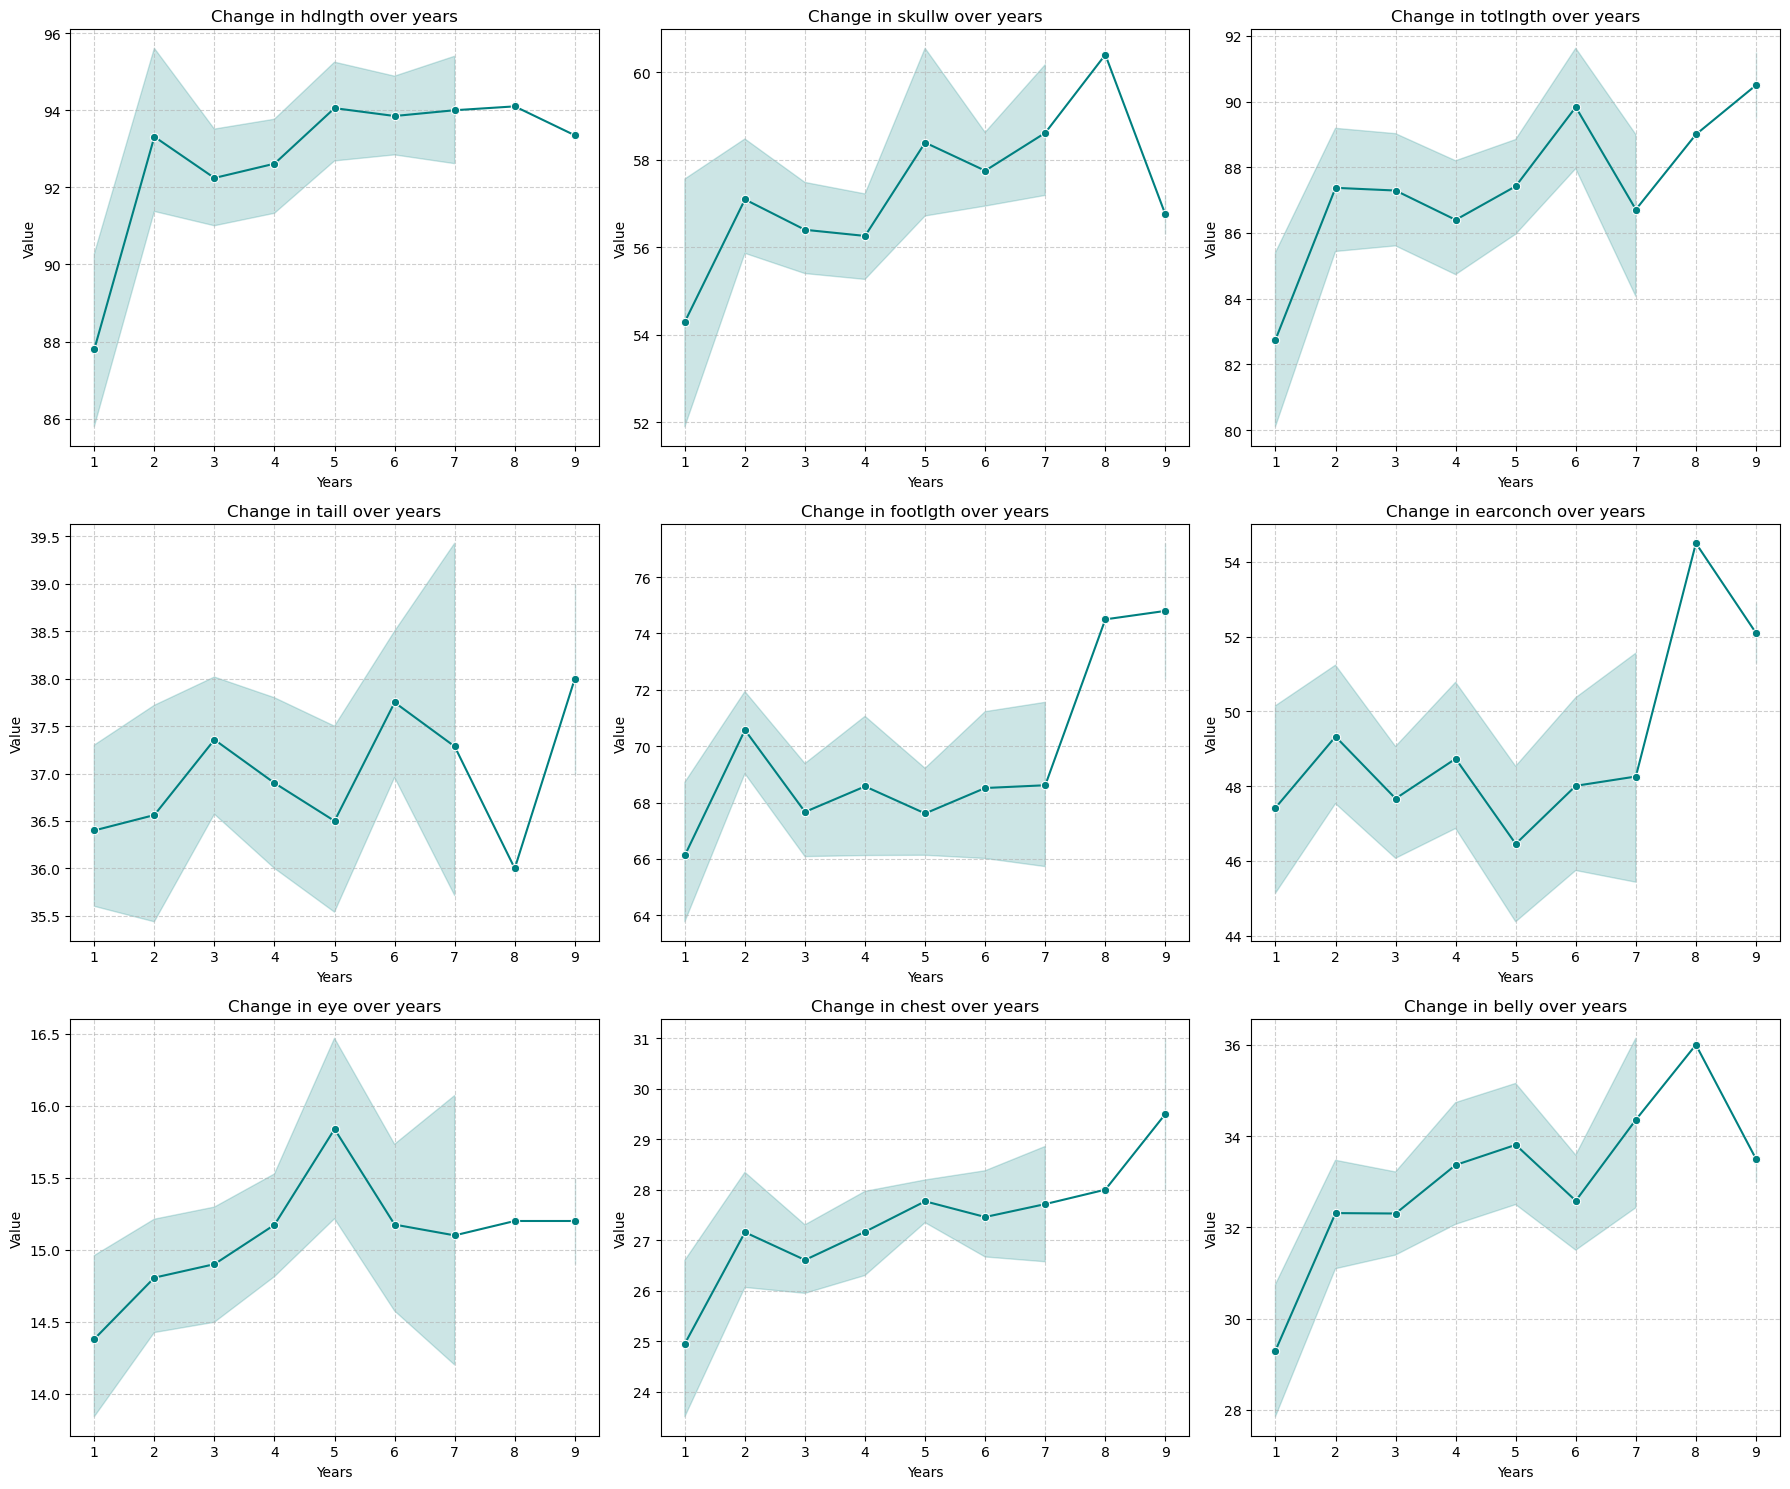

In [68]:
features_to_plot = ['hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.lineplot(data=complete_set2, x='age', y=col, ax=axes[i], marker='o', color='teal')
    axes[i].set_title(f'Change in {col} over years')
    axes[i].set_xlabel('Years')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The graphical representation of changes in morphological characteristics over the years provides a final explanation for the poor performance of the regression models. There is a clear absence of a linear or well-defined nonlinear growth trend. Such a distribution confirms that individual biological variation is greater than the differences caused by chronological aging, making morphometrics an unreliable tool for precise age estimation in adult individuals.

------------------------------------------------------

## 5.4. Conclusion
Nonlinearity – Opossums, regardless of sex, are animals that clearly reach a certain physical disposition at a certain age, making it difficult to estimate their age based on body measurements. Despite this nonlinearity, even more flexible models like RFR failed to achieve good results.<br>

Number of samples – The distribution showed that the number of older individuals is smaller compared to younger ones, so the model may not have had enough examples to learn what older individuals look like (especially those aged 8 and 9).<br>

Lack of information – The current attributes, regardless of their number, simply do not contain enough information to distinguish age.


In [69]:
youngs = complete_set2[(complete_set2['age'] == 1.0) | (complete_set2['age'] == 2.0)]
youngs = youngs.drop(['sex_f','sex_m','Pop_Vic','Pop_other','site'],axis = 1).mean()
youngs_list = youngs.drop('age').tolist()
youngs

age          1.615385
hdlngth     91.192308
skullw      56.019231
totlngth    85.596154
taill       36.500000
footlgth    68.865385
earconch    48.592308
eye         14.642308
chest       26.307692
belly       31.153846
dtype: float64

In [70]:
olds = complete_set2[(complete_set2['age'] != 1.0) & (complete_set2['age'] != 2.0)]
olds = olds.drop(['sex_f','sex_m','Pop_Vic','Pop_other','site'],axis = 1).mean()
olds_list = olds.drop('age').tolist()

olds

age          4.564103
hdlngth     93.073077
skullw      57.171795
totlngth    87.585897
taill       37.179487
footlgth    68.318974
earconch    47.976923
eye         15.180769
chest       27.230769
belly       33.064103
dtype: float64

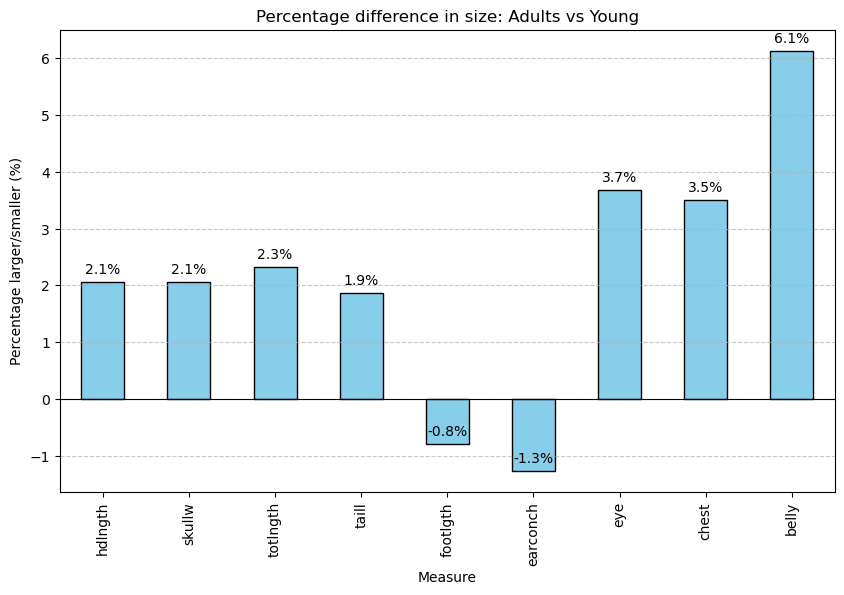

In [71]:
data = {
    'Measure': ['hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly'],
    'Young (1-2 yrs)': youngs_list,
    'Adults (3+ yrs)': olds_list
}
df_plot = pd.DataFrame(data).set_index('Measure')

df_plot['Difference (%)'] = ((df_plot['Adults (3+ yrs)'] / df_plot['Young (1-2 yrs)']) - 1) * 100

ax = df_plot['Difference (%)'].plot(kind='bar', figsize=(10,6), color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Percentage difference in size: Adults vs Young')
plt.ylabel('Percentage larger/smaller (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

By comparing the youngs and adults tables, and by observing the percentage difference graphs, it can be noticed that the dimensional differences between older and younger opossums are very small. There are even categories, such as ear conch length or foot length, that clearly develop during the first years of life and then later stagnate. These small percentage differences are another reason for the poor performance and inability of the regression models.

# 6. CONCLUSION
 This research provided a detailed insight into the possibilities and limitations of machine learning in the morphological analysis of opossums. In addition to the descriptive analysis of the dataset, it was concluded that this species differs more by geographical location than by sex or age. This trait is characteristic of marsupials, where external sexual differences are often subtle, suggesting that future research should include parameters of internal body composition (e.g., organ volume) for more precise differentiation.<br>

The logistic regression model with L1 penalization identified ear length (earconch) as the most significant morphological factor for distinguishing populations. SHAP analysis shows that individuals from Victoria have significantly higher values of this measure (red dots on the right side of the plot), while other variables such as sex and age had negligible impact on region classification.<br>

Another attempt I tried for sex classification was introducing L1 regularization (Lasso), since it proved successful in region classification. The result was an increase in accuracy to 0.78, but only because the model classified everything as male, which is also the majority in the test set (25 vs. 7). It was as if the model cared about accuracy rather than good generalization. The SHAP plot showed that Lasso set all features to zero, demonstrating that the model has no basis for distinguishing sexes.<br>

The logistic regression model with L1 penalization (Lasso) identified ear length (earconch) as the most important factor for recognizing individuals from Victoria. A major contribution of this work is robustness testing of the model, where successive removal of the strongest attributes (earconch, footlgth, taill) demonstrated the biological redundancy of the data. Although accuracy decreased (from 100% to 73% and finally to 66%), the model showed the ability to “find” alternative morphological markers until the moment of complete signal loss. The drop to 66% accuracy with an empty SHAP plot marked the model’s “white flag,” where it gave up on classification and switched to majority-class prediction.<br>

Finally, age prediction proved to be the most demanding task. Despite applying linear and nonlinear methods such as Random Forest, a negative $R^2$ score was obtained (-0.26). This result, combined with the moderate skewness of the data (Skewness = 0.544), indicates the existence of a biological growth ceiling. Opossums reach their full physical size early in life, after which morphological measures stagnate, making them no longer useful indicators for estimating the exact age of an individual.<br>

Since the regions South Wales and Queensland are grouped under the name other in the dataset, it would be worthwhile to try to find a dataset where these regions are represented separately and see whether there are differences in opossum morphology between them (especially because Queensland is a significantly larger territory). Such an analysis could be useful for scientific purposes, where researchers, volunteers, or nature-focused institutions could focus on specific physical elements (earconch, taill, footlgth), physical development over age, etc.

![Regije Australije](https://github.com/vekiii/ai-and-machine-learning/blob/main/machine-learning-projects/project1/sv.JPG?raw=1)